# NHS Data Analysis Project - Python notebook

## Section 1 - Approach

There are 4 excel files to analyse:
actual_duration
appointments_regional
national_categories
tweets

These will be imported using pandas into dataframes for analysis and visualisations to answer the questions posed by the NHS. Initial data validation will be performed on all imported dataframes as well as exploratory data analysis.
For simplicity the 3 appointment related dataframes will be imported as ad, ar and nc respectively. These will be analysed in similar ways in subsequent sections. Tweet data will be analysed seperately in Section 5.

## Section 2 - Establishing the dataframes and performing data validation

Importing all libraries requires for this script

In [1]:
# Import the necessary libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime
import re
from collections import Counter
import os

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Display days first for comfort of UK users
pd.options.display.date_dayfirst = True

In [2]:
# Checking starting directory for file pathing
os.getcwd()

'C:\\Users\\alext\\Course 2 Assignment'

Establishing some reusable data validation functions

In [3]:
# Creating a metadata funcion
def metadata(df):
    print("Dataframe shape - rows x columns:")
    print(df.shape)
    print("\nDataframe metadata:")
    df.info()

In [4]:
# Creating a repeatable data validation function
def validate_data(df):
    print("Number of unique values in Dataframe:")
    print(df.nunique())
    print("\nNumber of duplicated rows in Dataframe:")
    print(df.duplicated().sum())
    print("\nNumber of null values in Dataframe:")
    print(df.isna().sum())


In [5]:
# Import and sense-check the actual_duration.csv data set as ad.
# Amend file path on new workstation
ad = pd.read_csv('Assignment CSVS/actual_duration.csv') 

# View the DataFrame.
ad

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439


In [6]:
# Determine the metadata of the data set.
metadata(ad)

Dataframe shape - rows x columns:
(137793, 8)

Dataframe metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [7]:
# Observing unique values for categorical data in ad dataframe
ad_cat_cols = [
    'sub_icb_location_code',
    'sub_icb_location_ons_code',
    'sub_icb_location_name',
    'icb_ons_code',
    'region_ons_code',
    'actual_duration']
for col in ad_cat_cols:
    print(ad[col].unique())
    

['00L' '00N' '00P' '00Q' '00R' '00T' '00V' '00X' '00Y' '01A' '01D' '01E'
 '01F' '01G' '01H' '01J' '01K' '01T' '01V' '01W' '01X' '01Y' '02A' '02E'
 '02G' '02H' '02M' '02P' '02Q' '02T' '02X' '02Y' '03F' '03H' '03K' '03L'
 '03N' '03Q' '03R' '03W' '04C' '04V' '04Y' '05D' '05G' '05Q' '05V' '05W'
 '06H' '06K' '06L' '06N' '06Q' '06T' '07G' '07H' '07K' '09D' '10Q' '10R'
 '11J' '11M' '11N' '11X' '12F' '13T' '14L' '14Y' '15A' '15C' '15E' '15F'
 '15M' '15N' '16C' '18C' '26A' '27D' '36J' '36L' '42D' '52R' '70F' '71E'
 '72Q' '78H' '84H' '91Q' '92A' '92G' '93C' '97R' '99A' '99C' '99E' '99F'
 '99G' 'A3A8R' 'B2M3M' 'D2P2L' 'D4U1Y' 'D9Y0V' 'M1J4Y' 'M2L0M' 'W2U3Z'
 'X2C4Y']
['E38000130' 'E38000163' 'E38000176' 'E38000014' 'E38000015' 'E38000016'
 'E38000024' 'E38000034' 'E38000135' 'E38000050' 'E38000080' 'E38000227'
 'E38000068' 'E38000143' 'E38000215' 'E38000091' 'E38000228' 'E38000161'
 'E38000170' 'E38000174' 'E38000172' 'E38000263' 'E38000187' 'E38000194'
 'E38000200' 'E38000205' 'E38000226' 'E3800

In [8]:
# Data validation of the data set
validate_data(ad)

Number of unique values in Dataframe:
sub_icb_location_code         106
sub_icb_location_ons_code     106
sub_icb_location_name         106
icb_ons_code                   42
region_ons_code                 7
appointment_date              212
actual_duration                 7
count_of_appointments        7611
dtype: int64

Number of duplicated rows in Dataframe:
0

Number of null values in Dataframe:
sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64


In [9]:
# Determine the descriptive statistics of the data set.
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [10]:
# Import and sense-check the appointments_regional.csv data set as ar.
# Amend file path on new workstation
ar = pd.read_csv('Assignment CSVS/appointments_regional.csv')

# View the DataFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17


In [11]:
# Determine the metadata of the data set.
metadata(ar)

Dataframe shape - rows x columns:
(596821, 7)

Dataframe metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [12]:
# Data validation of the data set
validate_data(ar)

Number of unique values in Dataframe:
icb_ons_code                            42
appointment_month                       30
appointment_status                       3
hcp_type                                 3
appointment_mode                         5
time_between_book_and_appointment        8
count_of_appointments                22807
dtype: int64

Number of duplicated rows in Dataframe:
21604

Number of null values in Dataframe:
icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64


In [13]:
# Observing unique values for categorical data in ar dataframe
ar_cat_cols = [
    'icb_ons_code',
    'appointment_month',
    'appointment_status',
    'hcp_type',
    'appointment_mode',
    'time_between_book_and_appointment'
]
for col in ar_cat_cols:
    print(ar[col].unique())

['E54000034' 'E54000037' 'E54000044' 'E54000043' 'E54000051' 'E54000025'
 'E54000058' 'E54000062' 'E54000055' 'E54000031' 'E54000054' 'E54000027'
 'E54000036' 'E54000048' 'E54000057' 'E54000041' 'E54000013' 'E54000015'
 'E54000030' 'E54000061' 'E54000024' 'E54000011' 'E54000010' 'E54000019'
 'E54000026' 'E54000053' 'E54000018' 'E54000060' 'E54000029' 'E54000052'
 'E54000038' 'E54000039' 'E54000056' 'E54000042' 'E54000032' 'E54000022'
 'E54000023' 'E54000008' 'E54000028' 'E54000040' 'E54000059' 'E54000050']
['2020-01' '2020-02' '2020-03' '2020-04' '2020-05' '2020-06' '2020-07'
 '2020-08' '2020-09' '2020-10' '2020-11' '2020-12' '2021-01' '2021-02'
 '2021-03' '2021-04' '2021-05' '2021-06' '2021-07' '2021-08' '2021-09'
 '2021-10' '2021-11' '2021-12' '2022-01' '2022-02' '2022-03' '2022-04'
 '2022-05' '2022-06']
['Attended' 'DNA' 'Unknown']
['GP' 'Other Practice staff' 'Unknown']
['Face-to-Face' 'Home Visit' 'Telephone' 'Unknown' 'Video/Online']
['1 Day' '15  to 21 Days' '2 to 7 Days' '22  t

In [14]:
# Determine the descriptive statistics of the data set.
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [15]:
# Import and sense-check the national_categories.xlsx data set as nc.
# Amend file path on new workstation

nc = pd.read_excel('Assignment CSVs/national_categories.xlsx')

# View the DataFrame.
nc

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
...,...,...,...,...,...,...,...,...
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


In [16]:
# Determine the metadata of the data set.
metadata(nc)

Dataframe shape - rows x columns:
(817394, 8)

Dataframe metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [17]:
# Observing unique values for categorical data in nc dataframe
nc_cat_cols = [
    'icb_ons_code',
    'sub_icb_location_name',
    'service_setting',
    'context_type',
    'national_category',
    'appointment_month']
for col in nc_cat_cols:
    print(nc[col].unique())

['E54000050' 'E54000048' 'E54000057' 'E54000008' 'E54000061' 'E54000060'
 'E54000054' 'E54000051' 'E54000015' 'E54000010' 'E54000056' 'E54000025'
 'E54000023' 'E54000026' 'E54000053' 'E54000044' 'E54000042' 'E54000041'
 'E54000043' 'E54000036' 'E54000038' 'E54000039' 'E54000055' 'E54000058'
 'E54000037' 'E54000019' 'E54000022' 'E54000031' 'E54000013' 'E54000030'
 'E54000059' 'E54000032' 'E54000052' 'E54000040' 'E54000028' 'E54000029'
 'E54000018' 'E54000062' 'E54000034' 'E54000024' 'E54000011' 'E54000027']
['NHS North East and North Cumbria ICB - 00L'
 'NHS North East and North Cumbria ICB - 00N'
 'NHS North East and North Cumbria ICB - 00P'
 'NHS Lancashire and South Cumbria ICB - 00Q'
 'NHS Lancashire and South Cumbria ICB - 00R'
 'NHS Greater Manchester ICB - 00T' 'NHS Greater Manchester ICB - 00V'
 'NHS Lancashire and South Cumbria ICB - 00X'
 'NHS Greater Manchester ICB - 00Y'
 'NHS Lancashire and South Cumbria ICB - 01A'
 'NHS Greater Manchester ICB - 01D'
 'NHS Lancashire and So

In [18]:
# Seeing how many rows have "Unmapped" or "Inconsistent Mapping"
nc.groupby('service_setting').size()

service_setting
Extended Access Provision    108122
General Practice             359274
Other                        138789
Primary Care Network         183790
Unmapped                      27419
dtype: int64

In [19]:
# Data validation of the data set
validate_data(nc)

Number of unique values in Dataframe:
appointment_date          334
icb_ons_code               42
sub_icb_location_name     106
service_setting             5
context_type                3
national_category          18
count_of_appointments    9957
appointment_month          11
dtype: int64

Number of duplicated rows in Dataframe:
0

Number of null values in Dataframe:
appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64


In [20]:
# Determine the descriptive statistics of the data set.
nc.describe()

,appointment_date,count_of_appointments
count,817394,817394.000000
mean,2022-01-16 00:50:35.860796160,362.183684
min,2021-08-01 00:00:00,1.000000
25%,2021-10-25 00:00:00,7.000000
50%,2022-01-18 00:00:00,25.000000
75%,2022-04-07 00:00:00,128.000000
max,2022-06-30 00:00:00,16590.000000
std,NaN,1084.576600


## Initial exploratory questions

**Question 1:** How many locations are there in the data set?

In [21]:
# Determine the number of locations.
location_count = ad['sub_icb_location_code'].nunique()
print(f"The number of unique locations is {location_count}")


The number of unique locations is 106


**Question 2:** What are the five locations with the highest number of appointments?



In [22]:
# Determine the top five locations based on record count
ad_location_appointments_sum = (
    ad.groupby('sub_icb_location_name')['count_of_appointments']
    .sum()
)

print('The 5 locations with the highest number of appointments are:')
print(ad_location_appointments_sum.nlargest(5))

The 5 locations with the highest number of appointments are:
sub_icb_location_name
NHS North West London ICB - W2U3Z              6976986
NHS North East London ICB - A3A8R              5341883
NHS Kent and Medway ICB - 91Q                  5209641
NHS Hampshire and Isle Of Wight ICB - D9Y0V    4712737
NHS South East London ICB - 72Q                4360079
Name: count_of_appointments, dtype: int64


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [23]:
# Determine the number of service settings.
service_settings_unique = nc['service_setting'].nunique()
print(f"The number of different Service Settings is: {service_settings_unique}")

The number of different Service Settings is: 5


In [24]:
# Determine the number of context types.
context_types_unique = nc['context_type'].nunique()
print(f"The number of different Context Types is: {context_types_unique}")

The number of different Context Types is: 3


In [25]:
# Determine the number of national categories.
national_categories_unique = nc['national_category'].nunique()
print(f"The number of different National Categories is: {national_categories_unique}")

The number of different National Categories is: 18


In [26]:
# Determine the number of appointment statuses.
appointment_statuses_unique = ar['appointment_status'].nunique()
print(f"The number of different Appointment Statuses is: {appointment_statuses_unique}")

The number of different Appointment Statuses is: 3


## Section 3 - Further analysis

Continue to explore the data and search for answers to more specific questions posed by the NHS.

In [27]:
# Creating a backup of each dataframe in its original state and free from amendments in future code
ad_original = ad.copy()
ar_original = ar.copy()
nc_original = nc.copy()

**Question 1:** Between what dates were appointments scheduled? 

In [28]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
ad.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [29]:
# View the first five rows of appointment_month for the ar DataFrame to determine the date format.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [30]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [31]:
# Change the date of ad['appointment_date'] to a UK datetime format
ad['app_datetime'] = (
    pd.to_datetime(ad['appointment_date'], format='%d-%b-%y')
)    

# View the DateFrame.
ad.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments,app_datetime
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364,2021-12-01
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619,2021-12-01
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698,2021-12-01
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277,2021-12-01
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730,2021-12-01


In [32]:
# Change the type of ar['appointment_date'] to a period[M] format
ar['appointment_month'] = (
    pd.to_datetime(ar['appointment_month'], format='%Y-%m')
    .dt.to_period('M')
)

# View the DataFrame
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [33]:
# Changing the types of nc['appointment_date'] and nc['appointment_month']
# to datetime and period[M], respectively
nc['app_datetime'] = pd.to_datetime(nc['appointment_date'], format='%d-%b-%y')

nc['appointment_month'] = (
    pd.to_datetime(nc['appointment_month'], format='%Y-%m')
    .dt.to_period('M')
)

# View the DataFrame
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,app_datetime
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08,2021-08-02
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08,2021-08-02
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08,2021-08-02
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08,2021-08-02
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08,2021-08-02


In [34]:
# Determine the minimum and maximum dates in the ad DataFrame.
ad_date_max = ad['app_datetime'].max()
ad_date_min = ad['app_datetime'].min()
print(ad_date_max)
print(ad_date_min)

2022-06-30 00:00:00
2021-12-01 00:00:00


In [35]:
# Determine the minimum and maximum dates in the ar DataFrame.
ar_date_max = ar['appointment_month'].max()
ar_date_min = ar['appointment_month'].min()
print(ar_date_max)
print(ar_date_min)

2022-06
2020-01


In [36]:
# Determine the minimum and maximum dates in the nc DataFrame.
nc_date_max = nc['app_datetime'].max()
nc_date_min = nc['app_datetime'].min()
nc_month_max = nc['appointment_month'].max()
nc_month_min = nc['appointment_month'].min()
print(nc_date_max)
print(nc_date_min)
print(nc_month_max)
print(nc_month_min)

2022-06-30 00:00:00
2021-08-01 00:00:00
2022-06
2021-08


In [37]:
# Calculating a total number of appointments for use in percentages
total_appointments = nc['count_of_appointments'].sum()

#### Observations
All dataframes have data up to June 2022,however, they all start at different months based on when certain data was collectable. Future analysis will need to normalise date periods for consistency.

**Question 2:** Which service setting reported the most appointments in North West London from 1 January to 1 June 2022?

We will look at the last 6 months of data from 01-01-2022 to 30-06-2022

In [38]:
# Creating a mask for filtering the data
nw_london_2022 = (
    (nc['sub_icb_location_name'] == "NHS North West London ICB - W2U3Z") &
    (nc['appointment_date'].dt.year == 2022)
)

# Applying mask to create the subset data
nc_subset = nc.loc[nw_london_2022].copy()

# View output
nc_subset.head()


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,app_datetime
800289,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Unmapped,Unmapped,Unmapped,496,2022-01,2022-01-01
800290,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Clinical Triage,19,2022-01,2022-01-01
800291,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Other,Inconsistent Mapping,Inconsistent Mapping,1,2022-01,2022-01-01
800292,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Inconsistent Mapping,Inconsistent Mapping,16,2022-01,2022-01-01
800293,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Planned Clinics,29,2022-01,2022-01-01


In [39]:
# Calculating a total of subset appointments for % calculations
total_subset_apps = nc_subset['count_of_appointments'].sum()

# Grouping by service setting (ss)
nwl_2022_ss = (
    nc_subset
    .groupby('service_setting', as_index=False)['count_of_appointments']
    .sum()
)

# Adding a % of total subset appointments column
nwl_2022_ss['percent_of_subset'] = (
    nwl_2022_ss['count_of_appointments'] / total_subset_apps * 100
).round(1)

# Ordering the grouping
nwl_2022_ss = nwl_2022_ss.sort_values(
    'count_of_appointments',
    ascending=False
)

# View the output
nwl_2022_ss

,service_setting,count_of_appointments,percent_of_subset
1,General Practice,5719516,86.5
4,Unmapped,462758,7.0
2,Other,181576,2.7
3,Primary Care Network,130526,2.0
0,Extended Access Provision,115052,1.7


#### Observations
For this 6 month period 86.5% of all appoints in North West London were GP appointments. 7% are Unmapped which, as 2nd highest %, indicates a weakness in data quality controls.

In [40]:
# For each of these service settings, determine the number of records available for the period and the location. 
ss_aggregation = (
    nc.groupby('service_setting')['count_of_appointments']
    .sum()
    .reset_index()
    .sort_values(by='count_of_appointments', ascending=False)
)

# Adding a percentage column for the output
ss_aggregation['percent_of_total'] = (
    ss_aggregation['count_of_appointments'] / total_appointments * 100
).round(1)

# View the output.
ss_aggregation

,service_setting,count_of_appointments,percent_of_total
1,General Practice,270811691,91.5
4,Unmapped,11080810,3.7
3,Primary Care Network,6557386,2.2
2,Other,5420076,1.8
0,Extended Access Provision,2176807,0.7


In [41]:
# For each of national_category determine the total number of appointments
nc_aggregation = (
    nc.groupby('national_category')['count_of_appointments']
      .sum()
      .reset_index()
      .sort_values(by='count_of_appointments', ascending=False)
)

# Adding a percentage column for the output
nc_aggregation['percent_of_total'] = (
    nc_aggregation['count_of_appointments'] / total_appointments * 100
).round(1)

# View the output
nc_aggregation

,national_category,count_of_appointments,percent_of_total
4,General Consultation Routine,97271522,32.9
3,General Consultation Acute,53691150,18.1
2,Clinical Triage,41546964,14.0
11,Planned Clinics,28019748,9.5
7,Inconsistent Mapping,27890802,9.4
10,Planned Clinical Procedure,25702694,8.7
15,Unmapped,11080810,3.7
16,Unplanned Clinical Activity,3055794,1.0
6,Home Visit,2144452,0.7
14,Structured Medication Review,1858379,0.6


In [42]:
# For each of context_type determine the total number of appointments
ct_aggregation = (
    nc.groupby('context_type')['count_of_appointments']
      .sum()
      .reset_index()
      .sort_values(by='count_of_appointments', ascending=False)
)

# Adding a percentage column for the output
ct_aggregation['percent_of_total'] = (
    ct_aggregation['count_of_appointments'] / total_appointments * 100
).round(1)

# View the output
ct_aggregation

,context_type,count_of_appointments,percent_of_total
0,Care Related Encounter,257075158,86.8
1,Inconsistent Mapping,27890802,9.4
2,Unmapped,11080810,3.7


**Question 3:** Which month had the highest number of appointments?

In [43]:
# Number of appointments per month == sum of count_of_appointments by month.

""" For nc and ar (already have appointment_month as period[M]) """
nc_monthly = (
    nc.groupby('appointment_month')['count_of_appointments']
      .sum()
      .reset_index()
)

ar_monthly = (
    ar.groupby('appointment_month')['count_of_appointments']
      .sum()
      .reset_index()
)

""" For ad, first convert app_datetime to period[M] """
ad['appointment_month'] = ad['app_datetime'].dt.to_period('M')

ad_monthly = (
    ad.groupby('appointment_month')['count_of_appointments']
      .sum()
      .reset_index()
)


In [44]:
ad_monthly.head()

,appointment_month,count_of_appointments
0,2021-12,22853483
1,2022-01,23597196
2,2022-02,23351939
3,2022-03,27170002
4,2022-04,21948814


In [45]:
ar_monthly.head()

,appointment_month,count_of_appointments
0,2020-01,27199296
1,2020-02,24104621
2,2020-03,24053468
3,2020-04,16007881
4,2020-05,16417212


In [46]:
nc_monthly.head()

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776


In [47]:
# Showing the highest month for each table by finding the row index with the highest count of appointments

# For ad_monthly
ad_highest = ad_monthly.nlargest(1, 'count_of_appointments')

# View output
ad_highest

,appointment_month,count_of_appointments
3,2022-03,27170002


In [48]:
# For ar_monthly
ar_highest = ar_monthly.nlargest(1, 'count_of_appointments')

# View output
ar_highest

,appointment_month,count_of_appointments
22,2021-11,30405070


In [49]:
# For nc_monthly
nc_highest = nc_monthly.nlargest(1, 'count_of_appointments')

# View output
nc_highest

,appointment_month,count_of_appointments
3,2021-11,30405070


**Question 4:** What was the total number of records per month per data source?

For this we will combine the monthly aggregations calculated in question 3.

In [50]:
# Adding a 'source' column for data comparison
nc_monthly['source'] = 'nc'
ar_monthly['source'] = 'ar'
ad_monthly['source'] = 'ad'

# Combine monthly aggregations using concatenation
all_monthly = pd.concat([nc_monthly, ar_monthly, ad_monthly], ignore_index=True)

# View Output
all_monthly

,appointment_month,count_of_appointments,source
0,2021-08,23852171,nc
1,2021-09,28522501,nc
2,2021-10,30303834,nc
3,2021-11,30405070,nc
4,2021-12,25140776,nc
5,2022-01,25635474,nc
6,2022-02,25355260,nc
7,2022-03,29595038,nc
8,2022-04,23913060,nc
9,2022-05,27495508,nc


This format is not that useful so we will pivot by month to see each month ad, ar and nc for direct comparion

In [51]:
# Pivoting the data around appointment_month with source as columns
monthly_app_pivot = (
    all_monthly
    .pivot(index='appointment_month', columns='source', values='count_of_appointments')
    .fillna(0)
    .astype(int)
    .sort_index()
)

# View output
monthly_app_pivot

source,ad,ar,nc
appointment_month,,,
2020-01,0,27199296,0
2020-02,0,24104621,0
2020-03,0,24053468,0
2020-04,0,16007881,0
2020-05,0,16417212,0
2020-06,0,20690805,0
2020-07,0,22491437,0
2020-08,0,20150520,0
2020-09,0,26714255,0


#### Observation
This shows that ar has a substantially longer period of data collection than both ad and nc. There is only 7 months from Dec 21 to June 22 where all 3 tables have data.
Additionlly ar and nc match in total monthly appointment data once nc starts in Aug 21. However, ad appears to be lower indicating missing data for the actual_duration CSV.

# Visualisating national category data by month and season

Creating visualisations and identify possible monthly and seasonal trends in the data.

In [52]:
# Set figure size.
sns.set(rc={'figure.figsize':(12, 5)})

# Set the plot style as white.
sns.set_style('white')

### Monthly appointments for categorical data
Creating three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [53]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['app_month_str'] = pd.to_datetime(nc['appointment_month'].astype(str))

In [54]:
# Setting a threshold for national categories to be grouped as 'Other' if not greater than 1% of appointments
threshold = 1.0  # percent cutoff

# Categories to keep (above 1%)
keep_cats = nc_aggregation.loc[
    nc_aggregation['percent_of_total'] > threshold,
    'national_category'
].tolist()

# Remapping function
def remap_other(cat):
    if cat in keep_cats:
        return cat
    else:
        return 'Other'

# Creating a new mapped national category column
nc['national_category_remap'] = nc['national_category'].apply(remap_other)

In [55]:
# Define categories that we are interested in visualising
categories = [
    'service_setting',
    'context_type',
    'national_category_remap'
]

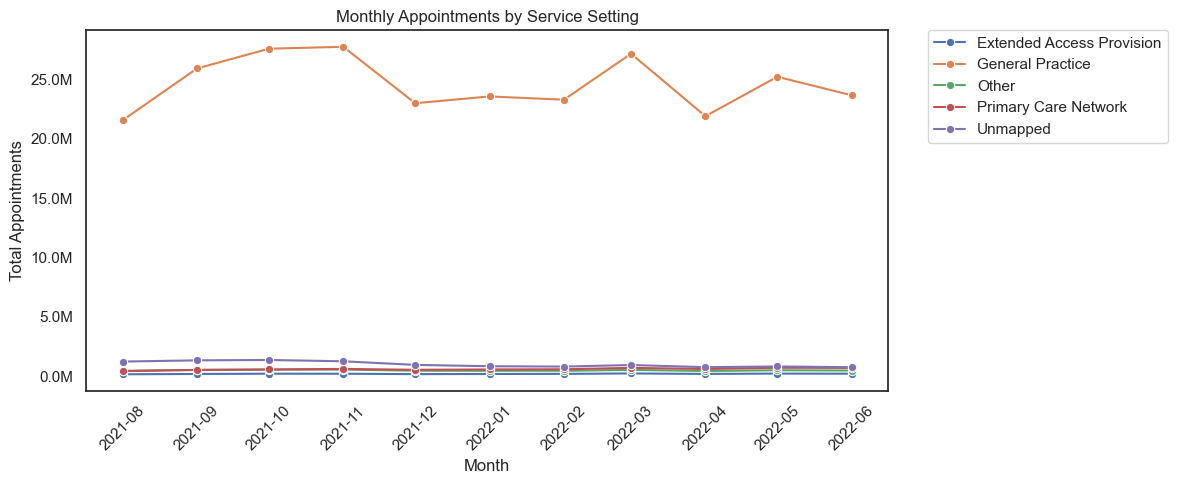

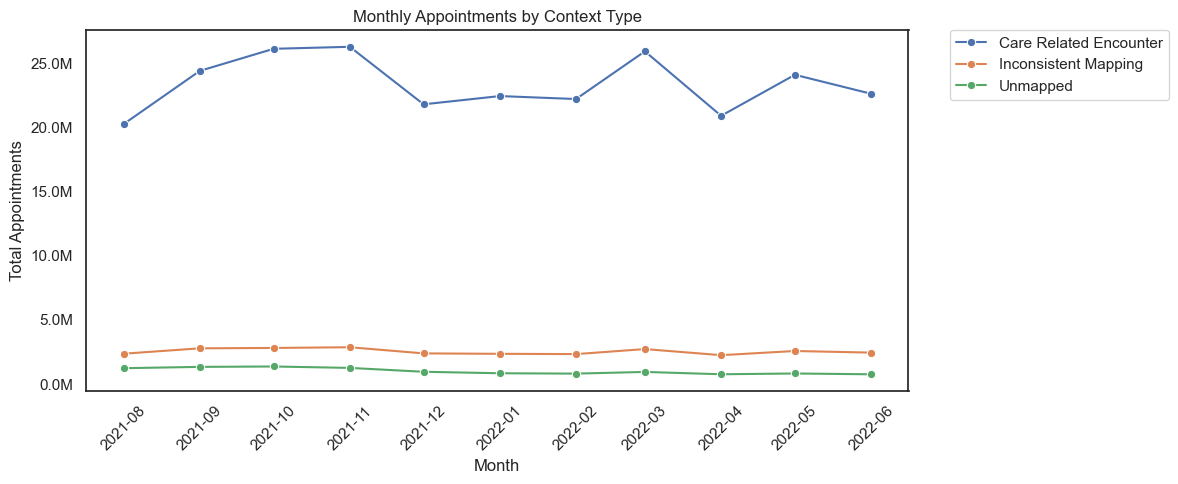

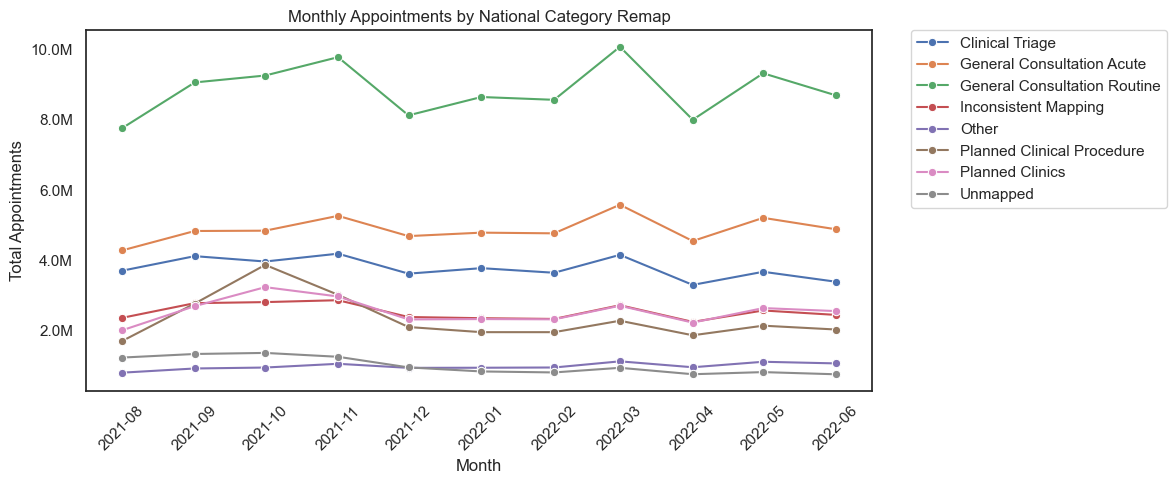

In [56]:
# Aggregate on monthly level and each categorical field
for cat in categories:
    grouped = (
        nc.groupby(['app_month_str', cat])['count_of_appointments']
          .sum()
          .reset_index()
    )

    # Create a line plot from aggregated data
    ax = sns.lineplot(
        data=grouped,
        x='app_month_str',
        y='count_of_appointments',
        hue=cat,
        marker='o'
    )

    # Format y-axis in millions for ease of reading
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
    )

    plt.title(f'Monthly Appointments by {cat.replace("_", " ").title()}')
    plt.xlabel('Month')
    plt.ylabel('Total Appointments')
    plt.xticks(rotation=45)

    # Moving legend box outside of the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    plt.tight_layout()

    # View output
    plt.show()

#### Observations
Service Settings:
General Practise makes up a significant majority of appointments (91.5%). No month is below 20M
Context Type:
Care Related Encounter makes up a significant majority of appointments (86.8%). No month is below 20M
National Category:
General Consultation Routine is the largest category (32.9%) predominantly between 8 and 10M per month.

### Seasonality
Creating visualisations for our categorical data for the different seasons

In [57]:
# Creating a season function based on the defined periods.
"""Seasons are assigned as follows:
Winter: December, January, February
Spring: March, April, May
Summer: June, July, August
Autumn: September, October, November"""
def month_to_season(dt):
    year = dt.year
    month = dt.month
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    elif month in [12, 1, 2]:
        return 'Winter'

In [58]:
# Converting appoint_month from period[M] to timestamp for easier month/year extraction
nc['appointment_month'] = nc['appointment_month'].dt.to_timestamp()

In [59]:
# Mapping to new season column with function above
nc['season'] = nc['appointment_month'].apply(month_to_season)

In [60]:
# Checking no missing values
nc['season'].unique()

array(['Summer', 'Autumn', 'Winter', 'Spring'], dtype=object)

In [61]:
# Creating a new grouping by season
season_data = (
    nc.groupby(
        ['season', 'service_setting', 'context_type', 'national_category_remap'],
        as_index=False
    )['count_of_appointments']
    .sum()
)

With the nc dataset there is no July data which would mean the Summer season visualisation would not be accurate. To correct we will extrapolate on the assumption that current data is 2/3 months i.e. multiply existing Summer counts by 1.5.

In [62]:
# Apply a correction factor for missing July (i.e. only 2/3 of Summer data present)
season_data['adjusted_count'] = season_data.apply(
    lambda row: (
        row['count_of_appointments'] * 1.5
        if row['season'] == 'Summer'
        else row['count_of_appointments']
    ),
    axis=1
)

In [63]:
season_data.head()

,season,service_setting,context_type,national_category_remap,count_of_appointments,adjusted_count
0,Autumn,Extended Access Provision,Care Related Encounter,Clinical Triage,103830,103830.0
1,Autumn,Extended Access Provision,Care Related Encounter,General Consultation Acute,104970,104970.0
2,Autumn,Extended Access Provision,Care Related Encounter,General Consultation Routine,101817,101817.0
3,Autumn,Extended Access Provision,Care Related Encounter,Other,30559,30559.0
4,Autumn,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,56681,56681.0


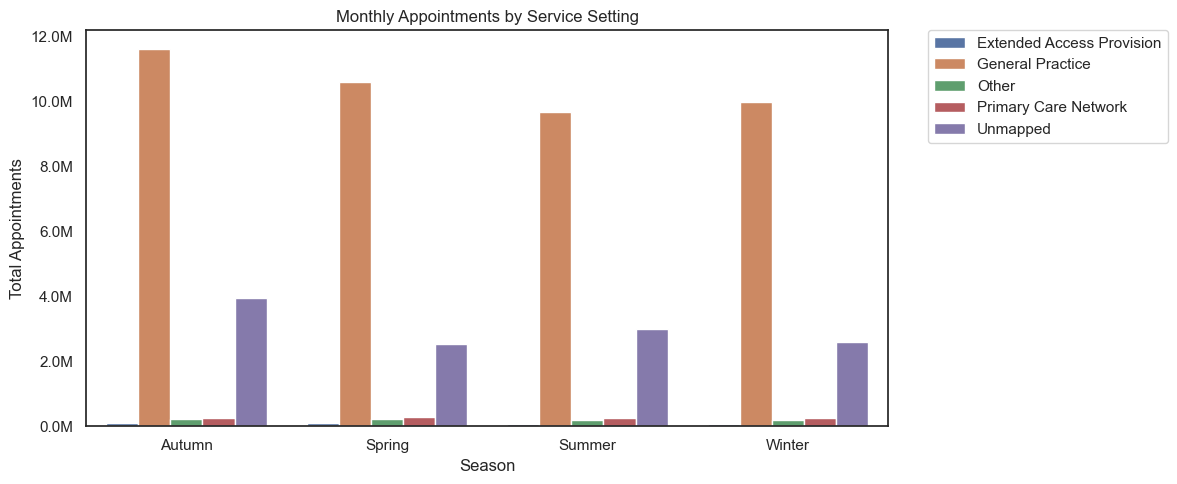

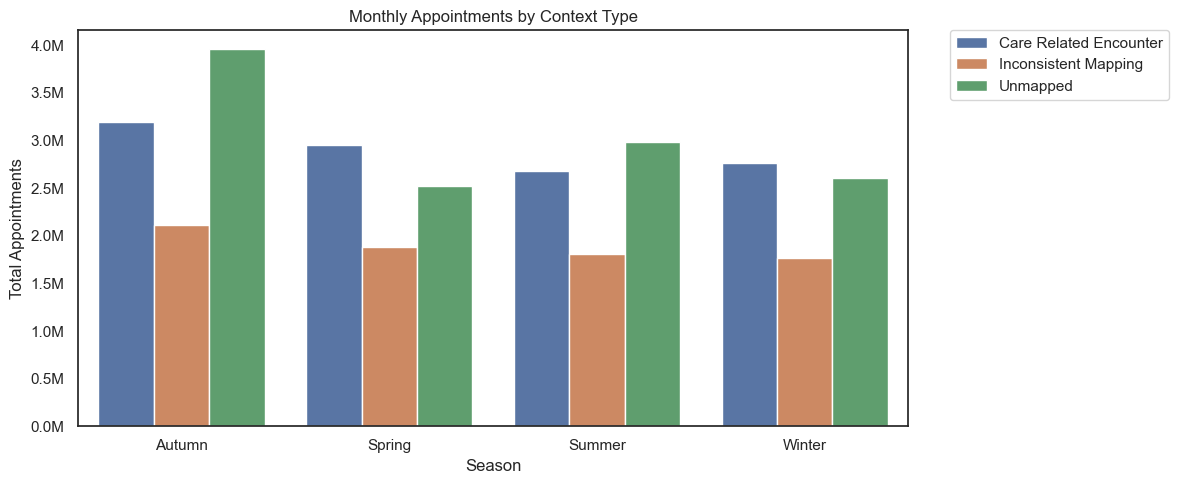

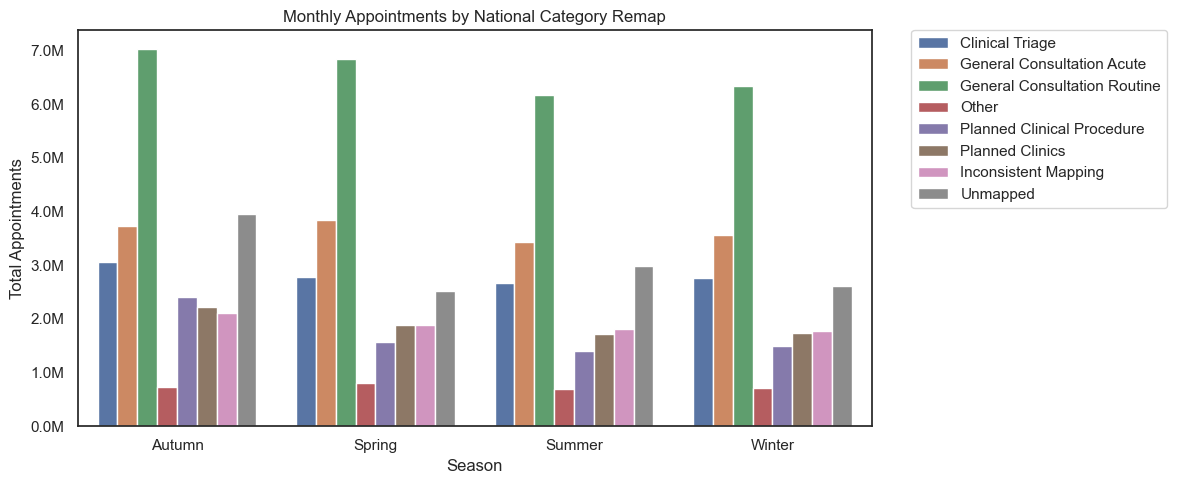

In [64]:
# Creating a bar plot for each categorical variable and showing each season
for cat in categories:
    ax = sns.barplot(
        data=season_data,
        x='season',
        y='adjusted_count',
        hue=cat,
        errorbar=None
    )

    plt.title(f'Monthly Appointments by {cat.replace("_", " ").title()}')
    plt.ylabel('Total Appointments')
    plt.xlabel('Season')

    # Format y-axis in millions for ease of reading
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
    )

    # Moving legend box outside of the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    plt.tight_layout()
    plt.show()

#### Observations
There is clear evidence of lower usage in Summer months even with an assumed extrapolation factor. This lower usage is the principle uses i.e. General Consultation/General Practice which is the majority of appointments. However, smaller categories such as "Planned Clinical Procedure" are more uniform and do not exhibit strong seasonality

## Analysing Twitter Data

Analysing tweets from Twitter with hashtags related to healthcare in the UK.

In [65]:
# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [66]:
# Load the data set.
twt = pd.read_csv('Assignment CSVS/tweets.csv')

# View the DataFrame.
twt

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
...,...,...,...,...,...,...,...,...,...,...
1169,1567583004209332227,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…,"{'hashtags': [{'text': 'Innovation', 'indices': [29, 40]}, {'text': 'precisionFabrication', 'indices': [50, 71]}, {'text': 'Microfluidic', 'indices': [92, 105]}], 'symbols': [], 'user_mentions': [...","#Innovation, #precisionFabrication, #Microfluidic","{'iso_language_code': 'en', 'result_type': 'recent'}",1,0,False,False,en
1170,1567582945342267393,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie...","{'hashtags': [{'text': 'SKPoli', 'indices': [232, 239]}, {'text': 'healthcare', 'indices': [240, 251]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/33f7Dz5FrU', 'expanded_u...","#SKPoli, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,1,False,False,en
1171,1567582936014241792,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp...","{'hashtags': [{'text': 'webinar', 'indices': [149, 157]}, {'text': 'ESG', 'indices'

In [67]:
# Explore the metadata.
metadata(twt)

Dataframe shape - rows x columns:
(1174, 10)

Dataframe metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB


In [68]:
# Explore the data set.
validate_data(twt)

Number of unique values in Dataframe:
tweet_id                   1174
tweet_full_text             961
tweet_entities              945
tweet_entities_hashtags     710
tweet_metadata                1
tweet_retweet_count          47
tweet_favorite_count         20
tweet_favorited               1
tweet_retweeted               1
tweet_lang                    1
dtype: int64

Number of duplicated rows in Dataframe:
0

Number of null values in Dataframe:
tweet_id                     0
tweet_full_text              0
tweet_entities               0
tweet_entities_hashtags    167
tweet_metadata               0
tweet_retweet_count          0
tweet_favorite_count         0
tweet_favorited              0
tweet_retweeted              0
tweet_lang                   0
dtype: int64


In [69]:
# Looking at numerical columns (ignoring tweet_id)
twt[['tweet_retweet_count', 'tweet_favorite_count']].describe()

,tweet_retweet_count,tweet_favorite_count
count,1174.000000,1174.00000
mean,8.629472,0.37138
std,29.784675,2.04470
min,0.000000,0.00000
25%,0.000000,0.00000
50%,1.000000,0.00000
75%,3.000000,0.00000
max,303.000000,42.00000


In [70]:
# Display rows where tweet_entities_hashtags are null
null_hashtags = twt[twt['tweet_entities_hashtags'].isna()]
null_hashtags

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
19,1567581972532174848,"RT @NNOCuba: Quite a claim to infamy, @marcorubio must be looking for $$$. The U.S. starvation plan was written before Rubio was born. Chec…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'NNOCuba', 'name': 'National Network on Cuba - NNOC', 'id': 2260844990, 'id_str': '2260844990', 'indices': [3, 11]}, {'screen_name...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",7,0,False,False,en
27,1567581274088566785,"RT @khaleejtimes: .@BurjeelHoldings, a private healthcare services provider, has partnered with superstar @iamsrk as its new brand ambassad…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'khaleejtimes', 'name': 'Khaleej Times', 'id': 18860860, 'id_str': '18860860', 'indices': [3, 16]}, {'screen_name': 'BurjeelHoldin...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",207,0,False,False,en
28,1567581257823027201,"RT @SoniaFurstenau: People in BC are dying of COVID, and more and more are enduring the serious impacts of long COVID. We are seeing the im…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'SoniaFurstenau', 'name': 'Sonia Furstenau', 'id': 2358617670, 'id_str': '2358617670', 'indices': [3, 18]}], 'urls': []}",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",40,0,False,False,en
38,1567580783598075905,"RT @ricochet_en: Health care in Canada is collapsing. “We’re beyond the worst-case scenario.” Now, provincial governments are pushing priva…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'ricochet_en', 'name': 'Ricochet Media', 'id': 2280019405, 'id_str': '2280019405', 'indices': [3, 15]}], 'urls': []}",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",72,0,False,False,en
40,1567580673682055168,RT @BambergHealth: Do you want to know about Health Digital Transformation in France?\n\nJoin stakeholders from France at the Healthcare Inno…,"{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'BambergHealth', 'name': 'Bamberg Health', 'id': 1313866524239835137, 'id_str': '1313866524239835137', 'indices': [3, 17]}], 'urls...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",1,0,False,False,en
...,...,...,...,...,...,...,...,...,...,...
1157,1567583777857101825,"RT @kelly_archives: When kidney function declines to a certain level, patients have end-stage renal disease and require either dialysis or…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'kelly_archives', 'name': 'Kelly Anderson', 'id': 1075811784156688384, 'id_str': '1075811784156688384', 'indices': [3, 18]}], 'url...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",1,0,False,False,en
1159,1567583678129393665,"RT @ricochet_en: Health care in Canada is collapsing. “We’re beyond the worst-case scenario.” Now, provincial governments are pushing priva…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'ricochet_en', 'name': 'Ricochet Media', 'id': 2280019405, 'id_str': '2280019405', 'indices': [3, 15]}], 'urls': []}",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",73,0,False,False,en
1160,1567583655689854978,"RT @khaleejtimes: .@BurjeelHoldings, a private healthcare services provider, has partnered with superstar @iamsrk as its new brand ambassad…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'khaleejtimes', 'name': 'Khaleej Times', 'id': 18860860, 'id_str': '18860860', 'indices': [3, 16]}, {'screen_name': 'BurjeelHoldin...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",208,0,False,False,en
1164,1567583442426028037,"RT @VBCExhibitHall: 🗞 VBC Newsstand Weekly: “CMS Releases the Latest MSSP Numbers, Touts Savings and Quality” &amp; more! 🗞\n\nCheck it out!! htt…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'VBCExhibitHall', 

In [71]:
# Remove rows with null in tweet_entities_hashtags
twt_clean = twt.dropna(subset=['tweet_entities_hashtags'])
twt_clean.shape

(1007, 10)

### Looking at favourite and retweet counts

In [72]:
# Counting non-zero retweets and favourites
total_tweets = len(twt_clean)  # Total number of tweets for percentage calculations

# Defining our metrics
nonzero_retweets = (twt_clean['tweet_retweet_count'] > 0).sum()
nonzero_favorites = (twt_clean['tweet_favorite_count'] > 0).sum()
both_nonzero = (
    (twt_clean['tweet_retweet_count'] > 0)
    & (twt_clean['tweet_favorite_count'] > 0)
).sum()
zero_both = (
    (twt_clean['tweet_retweet_count'] == 0)
    & (twt_clean['tweet_favorite_count'] == 0)
).sum()

# Creating our metrics dataframe
twt_metrics = pd.DataFrame({
    'Metric': [
        'Tweets with ≥1 Retweet',
        'Tweets with ≥1 Favorite',
        'Tweets with ≥1 of Both',
        'Tweets with 0 Retweets and Favorites'
    ],
    'Count': [
        nonzero_retweets,
        nonzero_favorites,
        both_nonzero,
        zero_both
    ],
    'Percent of Total': [
        f'{nonzero_retweets / total_tweets:.2%}',
        f'{nonzero_favorites / total_tweets:.2%}',
        f'{both_nonzero / total_tweets:.2%}',
        f'{zero_both / total_tweets:.2%}'
    ]
})

# View output
twt_metrics

,Metric,Count,Percent of Total
0,Tweets with ≥1 Retweet,482,47.86%
1,Tweets with ≥1 Favorite,147,14.60%
2,Tweets with ≥1 of Both,57,5.66%
3,Tweets with 0 Retweets and Favorites,435,43.20%


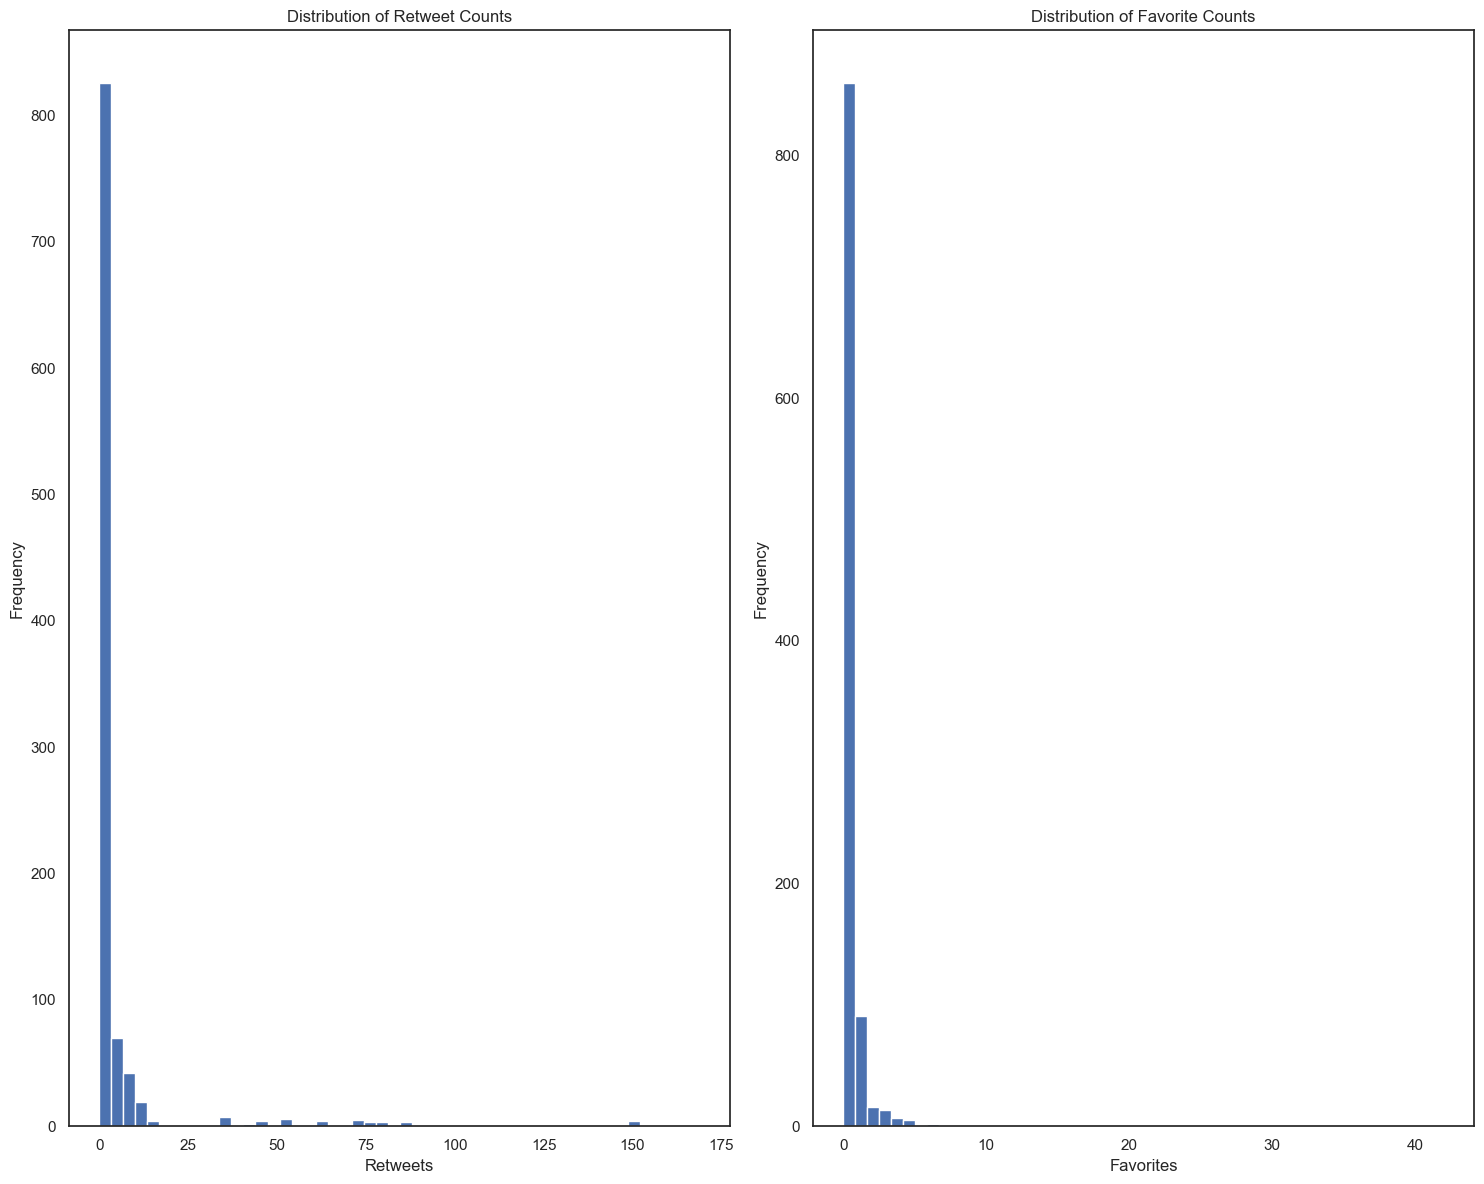

In [73]:
# Visualising the distribution of retweets and favourited tweets using a histogram
plt.subplot(1,2,1)
plt.hist(twt_clean['tweet_retweet_count'], bins=50)
plt.title('Distribution of Retweet Counts')
plt.xlabel('Retweets')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(twt_clean['tweet_favorite_count'], bins=50)
plt.title('Distribution of Favorite Counts')
plt.xlabel('Favorites')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


#### Observations
Over 50% of tweets have 0 retweets. Over 85% of tweets have 0 favourites.
Only 5.7% have both at least 1 retweet and 1 favourite.

### Looking at text data

In [74]:
# Create a new DataFrame containing only the text.
twt_text = twt_clean[['tweet_full_text']].copy()

# View the DataFrame.
twt_text.head()

,tweet_full_text
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."


In [75]:
# Loop through the messages, and create a list of values containing the # symbol.
hashtags_list = []

for msg in twt_text['tweet_full_text']:
    hashtags = re.findall(r'#\w+', msg) #regex code for finding words with a hasthtag
    hashtags_list.extend(hashtags)


In [76]:
# Display the first 30 records.
for tag in hashtags_list[:30]:
    print(tag)

#Healthcare
#PremiseHealth
#hiring
#Healthcare
#NEW
#blogs
#digitaltransformation
#cybersecurity
#accounting
#finance
#healthcare
#firstcoastcna
#cnaexam
#cnaexampreparation
#jacksonville
#cnatraining
#nurse
#nursing
#nurselife
#nursepractitioner
#nurseproblems
#nursingschool
#healthcare
#NEW
#disparities
#healthcare
#alert
#insurance
#data
#Healthcare


In [77]:
# Converting all hashtags to lower case as Twitter/X is case insensitive for hasthtags
hashtags_list = [h.lower() for h in hashtags_list]

In [78]:
# Convert the series to a DataFrame in preparation for visualisation.
hashtag_count = Counter(hashtags_list) #Counting frequency of the hashtags
ht = pd.DataFrame(hashtag_count.items(), columns=['Hashtag', 'Count']) 

In [79]:
# Checking our new ht dataframe
metadata(ht)
ht.head()

Dataframe shape - rows x columns:
(1544, 2)

Dataframe metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Hashtag  1544 non-null   object
 1   Count    1544 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 24.3+ KB


,Hashtag,Count
0,#healthcare,844
1,#premisehealth,5
2,#hiring,21
3,#new,13
4,#blogs,1


In [80]:
# Adding a % total column to ht
total_hashtags = ht['Count'].sum() #A reusable total count

ht['Percent'] = ((ht['Count'] / total_hashtags) * 100).round(1)

# View Output
ht.head()

,Hashtag,Count,Percent
0,#healthcare,844,19.4
1,#premisehealth,5,0.1
2,#hiring,21,0.5
3,#new,13,0.3
4,#blogs,1,0.0


In [81]:
# Display records where the count is larger than 10.
popular_benchmark = 10 #Define the popularity threshold

# Filter hashtags using our threshold
popular_ht = ht[ht['Count'] > popular_benchmark]

# Sort by descending
popular_ht = popular_ht.sort_values(by='Count', ascending=False)

# View output
popular_ht


,Hashtag,Count,Percent
0,#healthcare,844,19.4
78,#health,88,2.0
31,#ai,47,1.1
83,#medicine,42,1.0
27,#job,38,0.9
84,#medical,35,0.8
195,#digitalhealth,31,0.7
87,#strategy,31,0.7
95,#pharmaceutical,28,0.6
82,#medtwitter,27,0.6


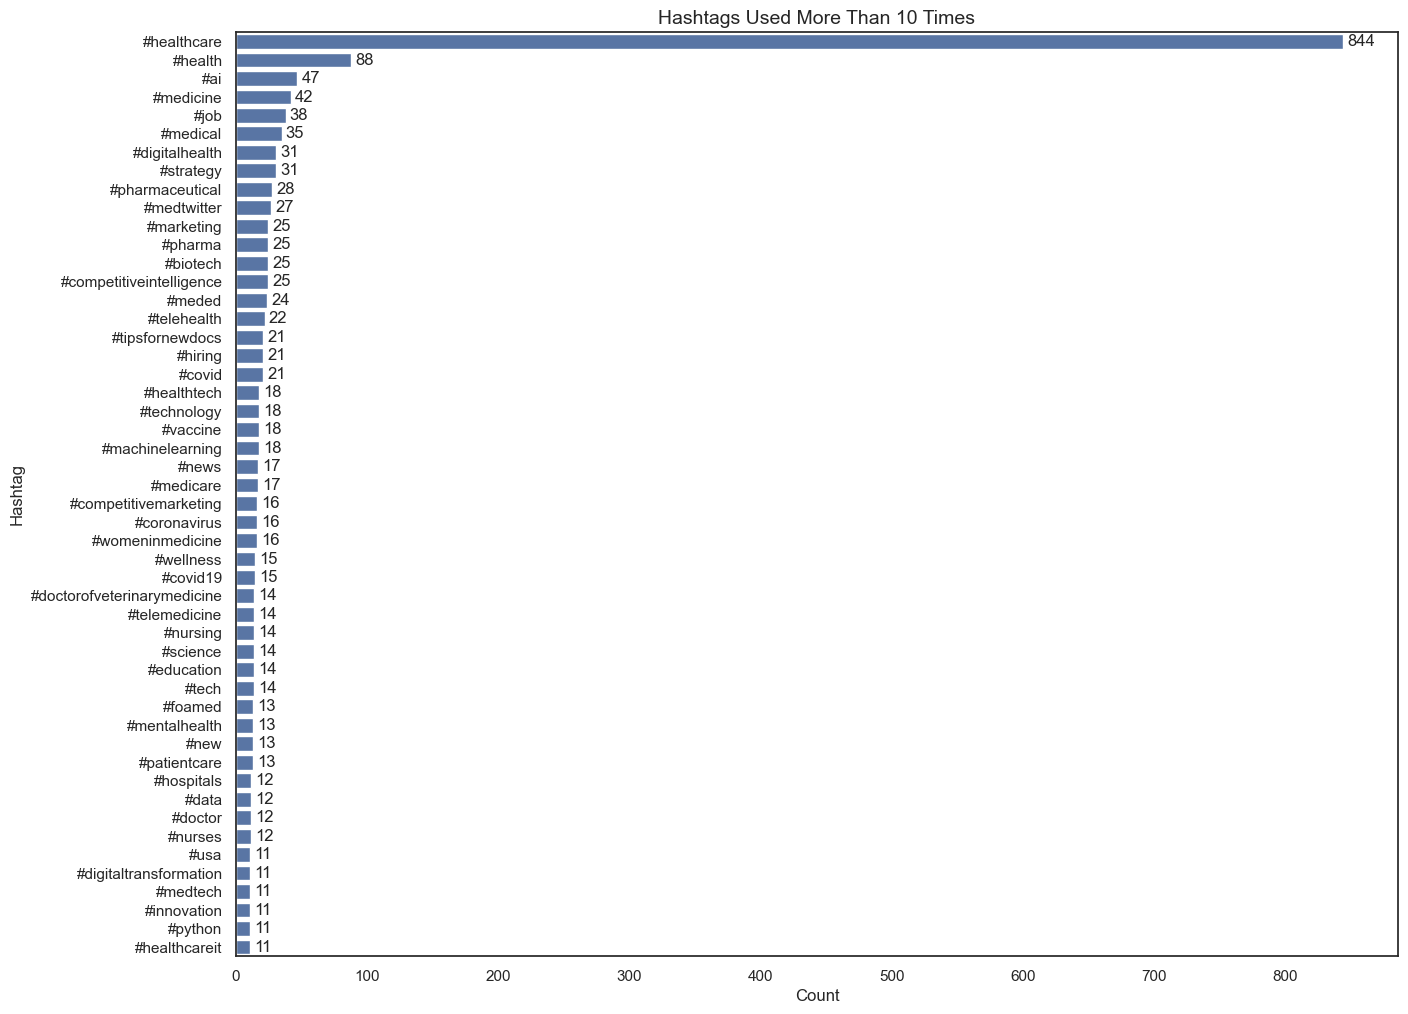

In [82]:
# Create a Seaborn barplot indicating records with a count >10 records.
ax = sns.barplot(data=popular_ht, x='Count', y='Hashtag')

# Adding count labels to each bar
for i in ax.containers:
    ax.bar_label(i, label_type='edge', padding=3)

# Formatting title and axis
plt.title(f"Hashtags Used More Than {popular_benchmark} Times", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Hashtag", fontsize=12)

plt.show()

#healthcare clearly dominate the chart. We will now remove that for better scaling on other hashtags.

In [83]:
# Defining a filter list that can be added to and used in the future to remove multiple hashtags
ht_filter = ['#healthcare']

# Applying filter to ht dataframe
ht_filtered = ht[~ht['Hashtag'].isin(ht_filter)]

# Filter hashtags using our threshold
popular_ht = ht_filtered[ht_filtered['Count'] > popular_benchmark]

# Sort by descending
popular_ht = popular_ht.sort_values(by='Count', ascending=False)

# View output
popular_ht


,Hashtag,Count,Percent
78,#health,88,2.0
31,#ai,47,1.1
83,#medicine,42,1.0
27,#job,38,0.9
84,#medical,35,0.8
195,#digitalhealth,31,0.7
87,#strategy,31,0.7
95,#pharmaceutical,28,0.6
82,#medtwitter,27,0.6
91,#marketing,25,0.6


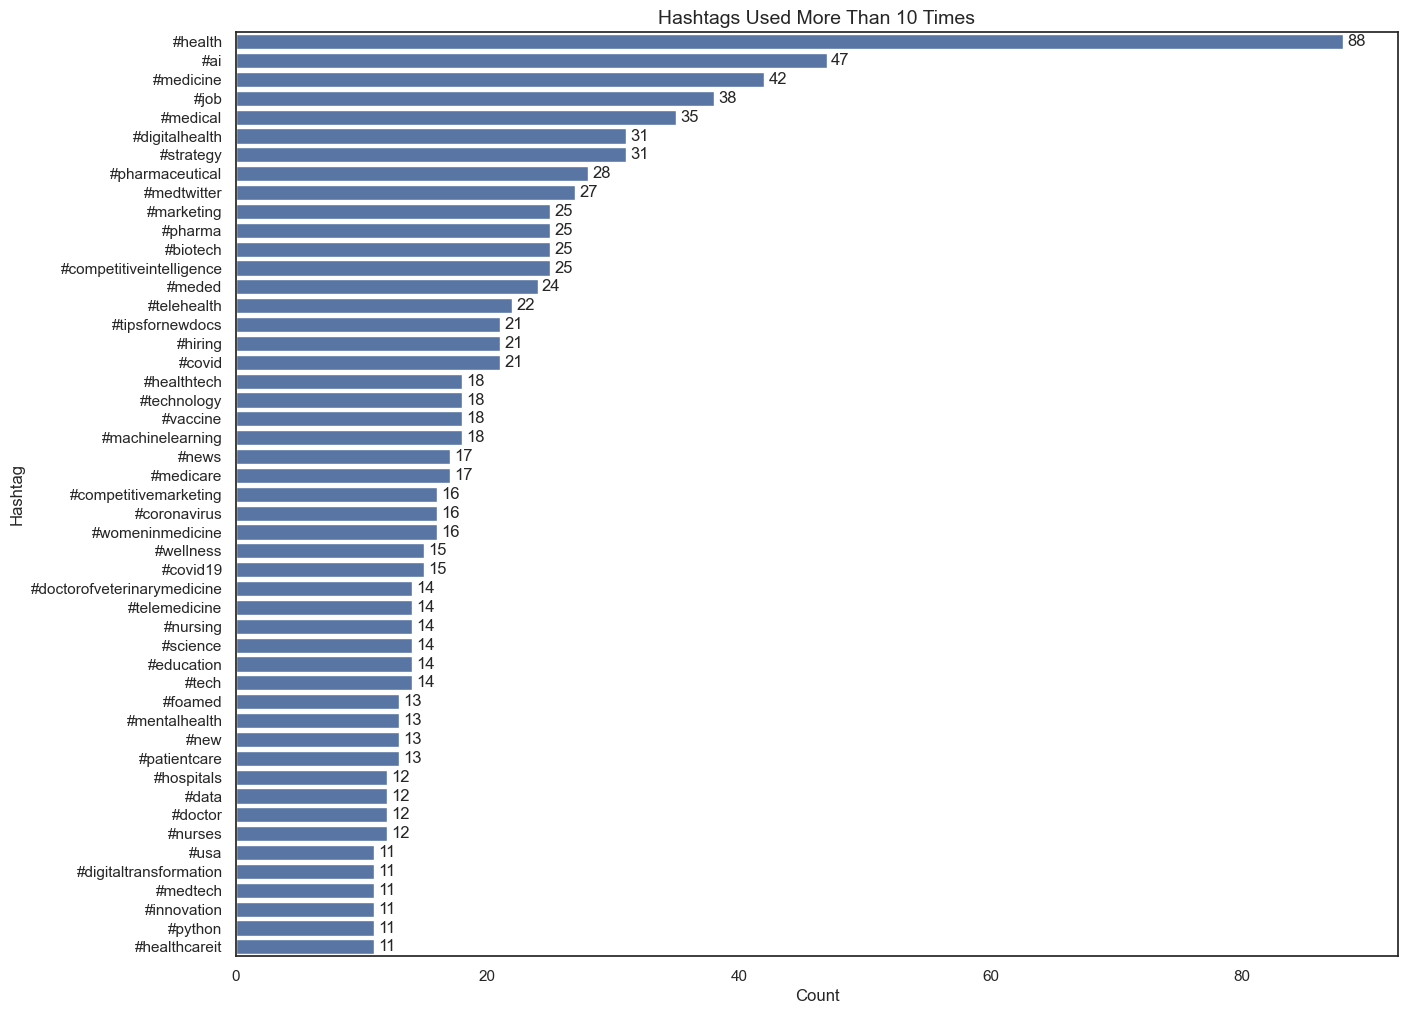

In [84]:
# Repeating the earlier bar plot but now without #healthcare
popular_ht = popular_ht.sort_values(by='Count', ascending=False) # Sort descending for clearer barplot

# Creating the plot
ax = sns.barplot(data=popular_ht, x='Count', y='Hashtag')

# Adding count labels to each bar
for i in ax.containers:
    ax.bar_label(i, label_type='edge', padding=3)

# Formatting title and axis
plt.title(f"Hashtags Used More Than {popular_benchmark} Times", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Hashtag", fontsize=12)

plt.show()

#### Observations
#healthcare is the most commonly used hashtag accounting for 19.4% of all hashtags. The next highest #health was only 2%.

## Analysing appointments_regional data set

Initial data validation and metadata analyis for the ar dataframe was performed earlier in this workbook and won't be repeated here.
Additionally 'appointment_month' with type period[M] was also created earlier.


In [85]:
# Print the min and max dates.
ar_date_max = ar['appointment_month'].max()
ar_date_min = ar['appointment_month'].min()
print(ar_date_max)
print(ar_date_min)

2022-06
2020-01


As nc and ad datasets only start from 2021-08 we will apply this filter to ar as well.

In [86]:
# Converting appointment_month to timestamp format for easier manipulation
ar['appointment_month'] = ar['appointment_month'].dt.to_timestamp()

# Filter for 2021-08 and later
ar_filtered = ar[ar['appointment_month'] >= '2021-08']

# View new min and max to verify
print(ar_filtered['appointment_month'].max())
print(ar_filtered['appointment_month'].min())

2022-06-01 00:00:00
2021-08-01 00:00:00


In [87]:
ar_filtered.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E54000034,2021-08-01,Attended,GP,Face-to-Face,1 Day,6553
3653,E54000034,2021-08-01,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E54000034,2021-08-01,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E54000034,2021-08-01,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E54000034,2021-08-01,Attended,GP,Face-to-Face,8 to 14 Days,4961


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [88]:
# Creating an aggregation list
agg_columns = [
    'appointment_month',
    'hcp_type',
    'appointment_status',
    'appointment_mode','time_between_book_and_appointment'
]

# Create an aggregated data set to review the different features.
ar_agg = (
    ar_filtered
    .groupby(agg_columns)['count_of_appointments']
    .sum()
    .reset_index()
)

# View the DataFrame.
ar_agg.head()

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08-01,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08-01,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08-01,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08-01,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08-01,GP,Attended,Face-to-Face,8 to 14 Days,398772


In [89]:
# Determine the total number of appointments per month
ar_df = (
    ar_filtered
    .groupby('appointment_month')['count_of_appointments']
    .sum()
    .reset_index()
)
# View the DataFrame
ar_df

,appointment_month,count_of_appointments
0,2021-08-01,23852171
1,2021-09-01,28522501
2,2021-10-01,30303834
3,2021-11-01,30405070
4,2021-12-01,25140776
5,2022-01-01,25635474
6,2022-02-01,25355260
7,2022-03-01,29595038
8,2022-04-01,23913060
9,2022-05-01,27495508


We know the NHS has an estimated 1.2million appointments a day capacity. We will use this for some visualisations.

In [90]:
# Set max_capacity variable
max_daily_capacity = 1200000

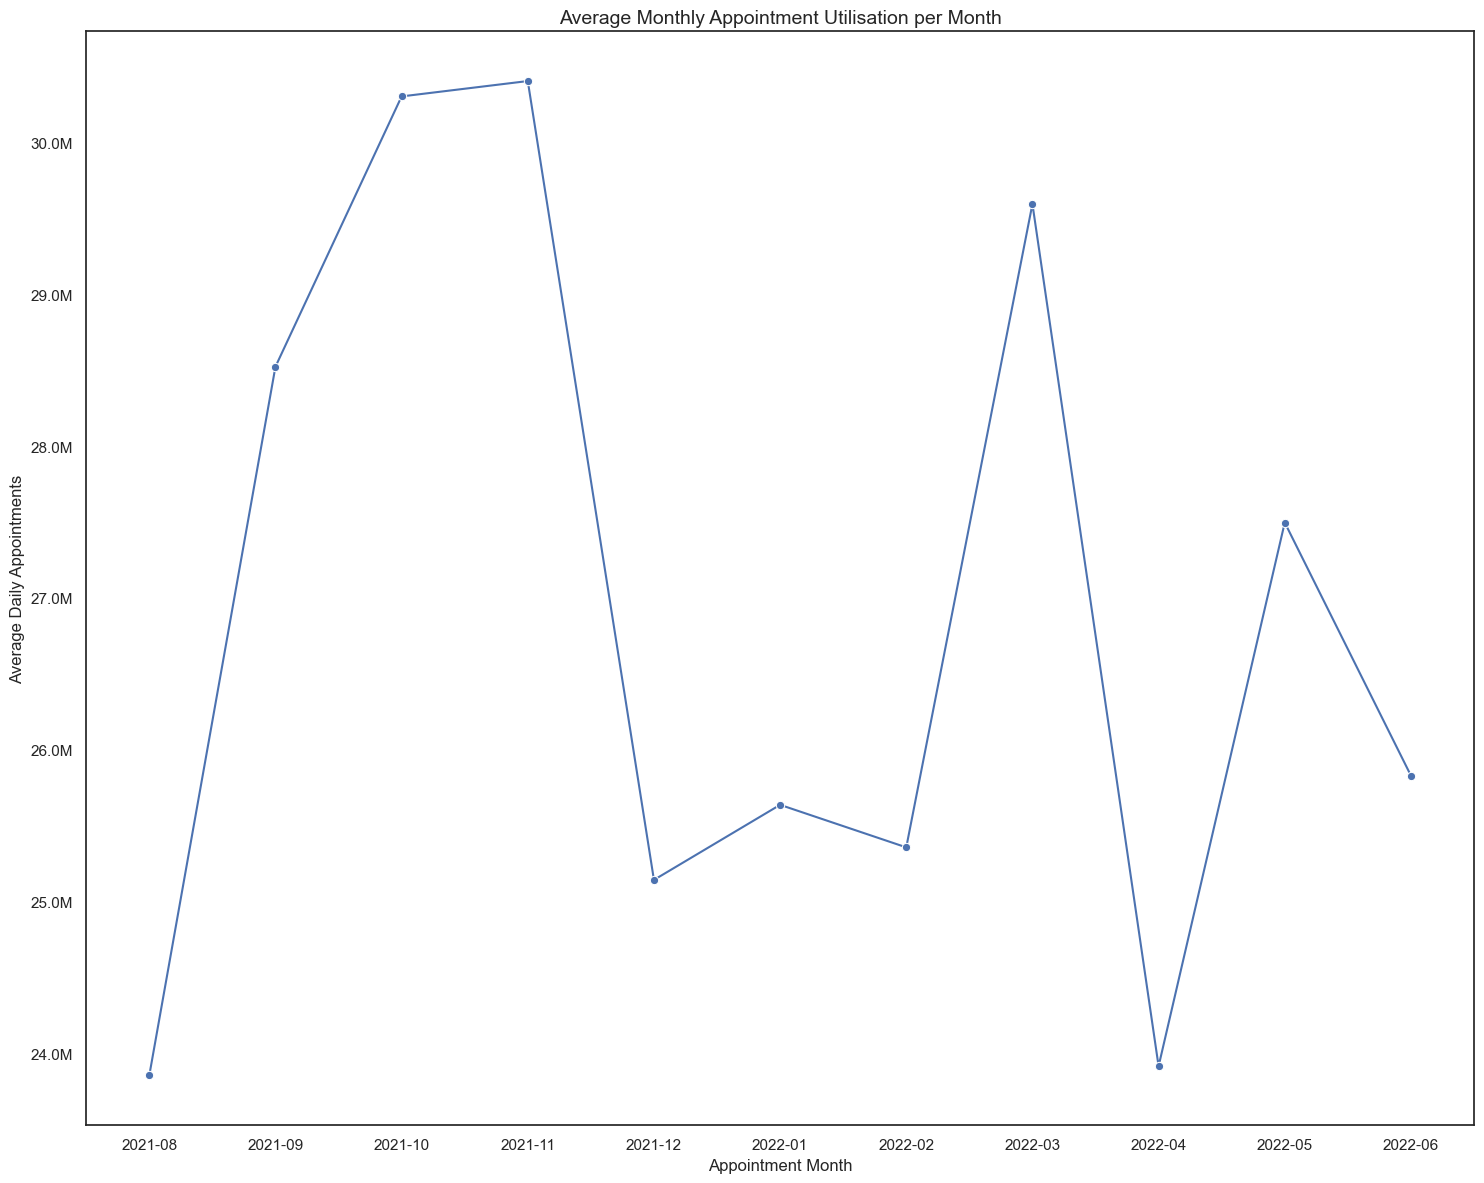

In [91]:
# Creating an appointment month string column for ease of visualisation
ar_df['appointment_month_str'] = ar_df['appointment_month'].dt.strftime('%Y-%m')

# Create a lineplot with Seaborn
ax = sns.lineplot(
    data=ar_df,
    x='appointment_month_str',
    y='count_of_appointments',
    marker='o'
)

# Formatting title and axis
plt.title('Average Monthly Appointment Utilisation per Month', fontsize=14)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Average Daily Appointments', fontsize=12)

# Format y-axis in millions for ease of reading
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)

# View output
plt.tight_layout()
plt.show()

Now we will add a monthly capacity line for comparison assuming 30 days per month.

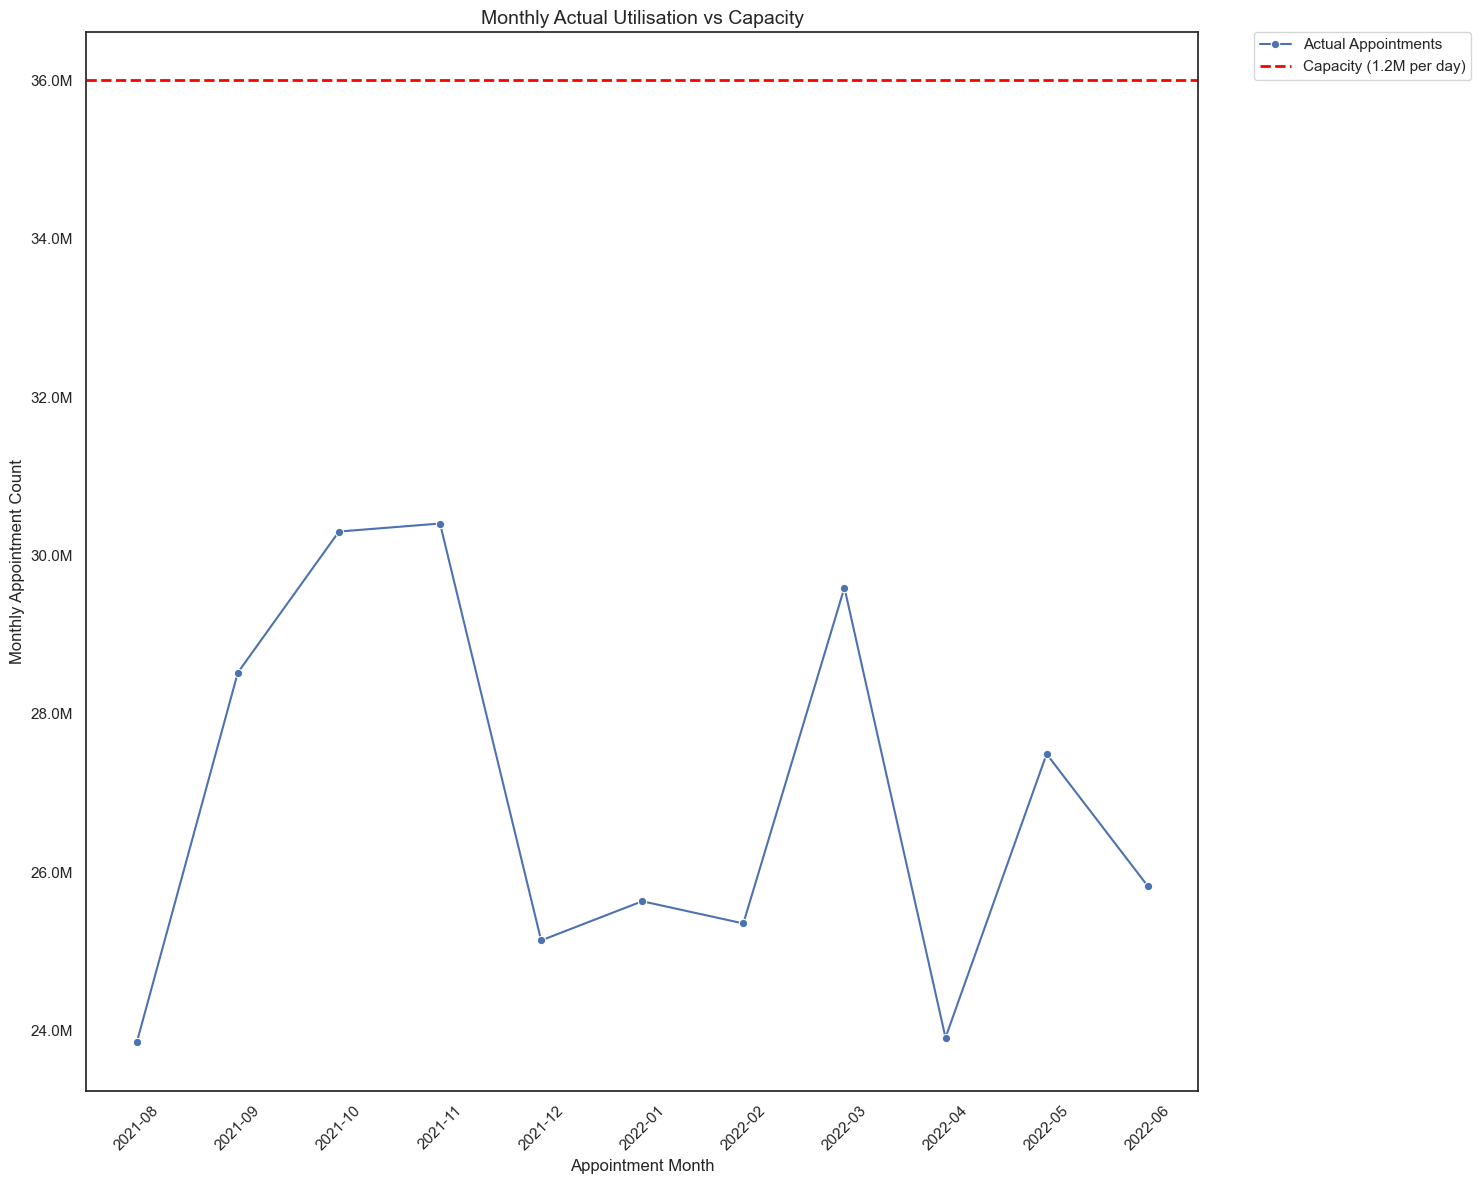

In [92]:
# Plot monthly capacity utilisation
monthly_capacity = max_daily_capacity * 30  # Multiplying stated daily capacity by 30 days

# Create a lineplot
ax = sns.lineplot(
    data=ar_df,
    x='appointment_month_str',
    y='count_of_appointments',
    marker='o',
    label='Actual Appointments'
)

# Plot constant capacity line
ax.axhline(
    monthly_capacity,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Capacity (1.2M per day)'
)

# Formatting title and axis
plt.title('Monthly Actual Utilisation vs Capacity', fontsize=14)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Monthly Appointment Count', fontsize=12)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)

# Add legend for the two lines and move it outside the chart
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# View output
plt.tight_layout()
plt.show()


#### Observations
It would appear, based on the estimated daily capacity of 1.2m, that the NHS has not exceeded operational capacity in any month between August 2021 and June 2022. 
This observation has some inherent limitations: it assumes capacity and utilisation is uniform across the country and it assumes all 30 days in a month have equal capacity - it is likely weekends and especially Sundays this capacity is lower.

### Looking at healthcare professionals over time

In [93]:
# Creating string column for appointment month
ar_filtered['appointment_month_str'] = (
    ar_filtered['appointment_month'].dt.strftime('%Y-%m')
)

# Aggregating by month and healthcare professional type
hcp_agg = (
    ar_filtered
    .groupby(['appointment_month_str', 'hcp_type'])['count_of_appointments']
    .sum()
    .reset_index()
)


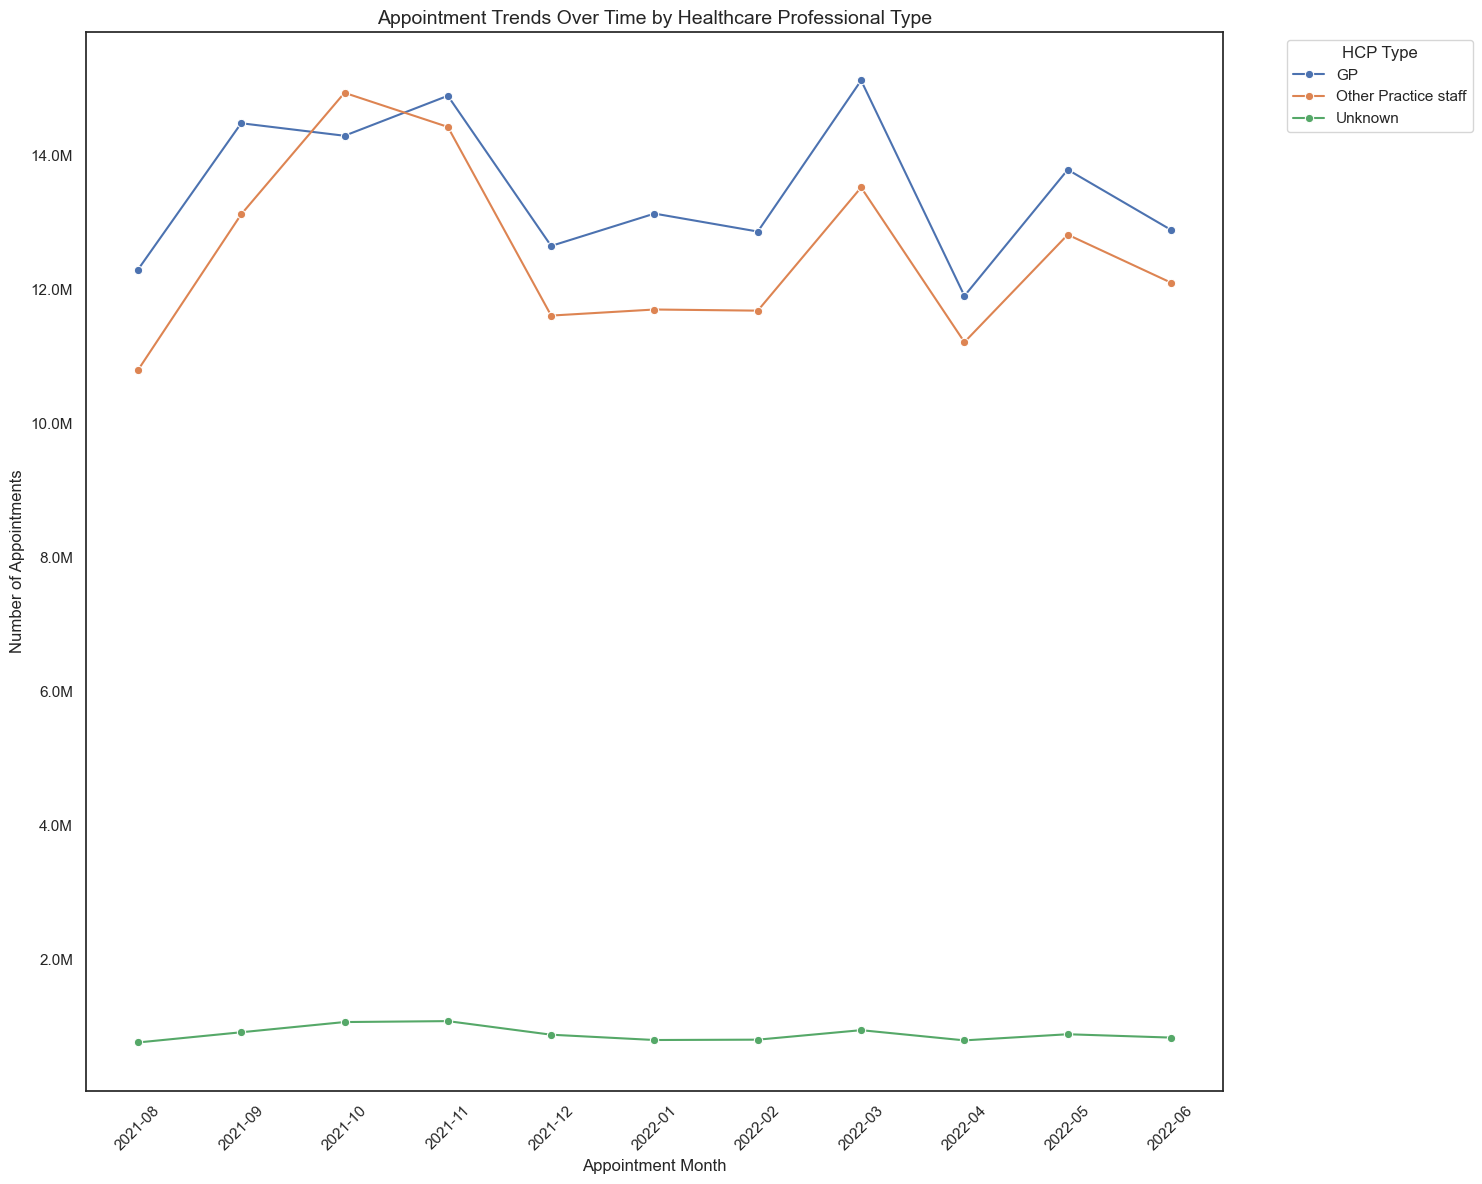

In [94]:
# Creating a line plot for hcp_agg
ax = sns.lineplot(
    data=hcp_agg,
    x='appointment_month_str',
    y='count_of_appointments',
    hue='hcp_type',
    marker='o'
)

# Formatting title and axis
plt.title(
    'Appointment Trends Over Time by Healthcare Professional Type',
    fontsize=14
)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)

# Moving legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='HCP Type')

plt.tight_layout()
plt.show()

#### Observations
No discernible trends identified. The difference in usage between  GP and Other Practice staff remains fairly constant with one exception (Oct 2010). When GP usage rises so does the usage of Other Practice staff at a comensurate rate.

### Analysing appointment attendance

In [95]:
# Aggregating by appointment_status
attendance_agg = (
    ar_filtered
    .groupby(['appointment_month_str', 'appointment_status'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Renaming 'DNA' to 'Not Attended' in appointment_status for clearer comprehension
attendance_agg['appointment_status'] = attendance_agg['appointment_status'].replace(
    'DNA',
    'Not Attended'
)

# View output
attendance_agg.head()

,appointment_month_str,appointment_status,count_of_appointments
0,2021-08,Attended,22081765
1,2021-08,Not Attended,949137
2,2021-08,Unknown,821269
3,2021-09,Attended,25757066
4,2021-09,Not Attended,1321348


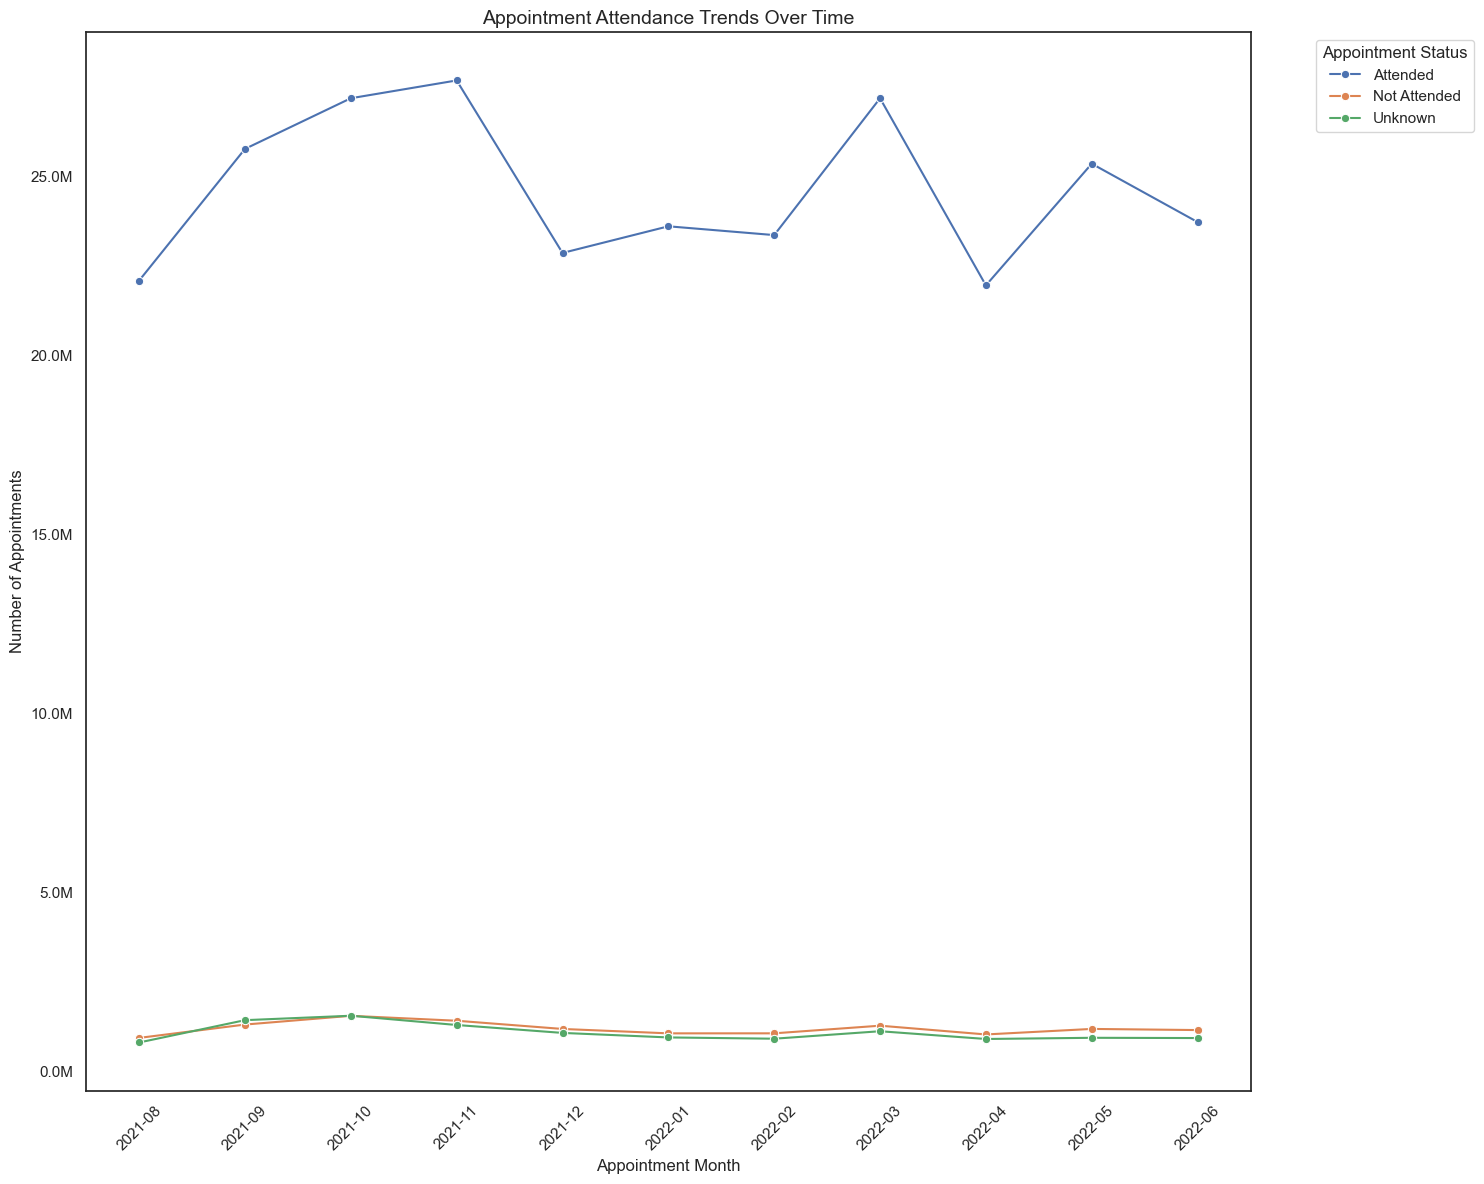

In [96]:
# Creating a line plot for attendance_agg
ax = sns.lineplot(
    data=attendance_agg,
    x='appointment_month_str',
    y='count_of_appointments',
    hue='appointment_status',
    marker='o'
)

# Formatting title and axis
plt.title('Appointment Attendance Trends Over Time', fontsize=14)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)

# Moving legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Appointment Status')

plt.tight_layout()
plt.show()

Not attended appointments do not seem to vary month to month proportionally to total appointments. Additional analysis performed below.

#### Observations
No discernible increase or decrease in appointments not being attended. The level is fairly consistent even accounting for 'Unknown' appointment statuses.

### Analysing appointment types and busiest months

In [97]:
# Aggregating by appointment_mode
mode_agg = (
    ar_filtered
    .groupby(['appointment_month_str', 'appointment_mode'])['count_of_appointments']
    .sum()
    .reset_index()
)

# View output
mode_agg.head()

,appointment_month_str,appointment_mode,count_of_appointments
0,2021-08,Face-to-Face,13717325
1,2021-08,Home Visit,151619
2,2021-08,Telephone,9149072
3,2021-08,Unknown,724126
4,2021-08,Video/Online,110029


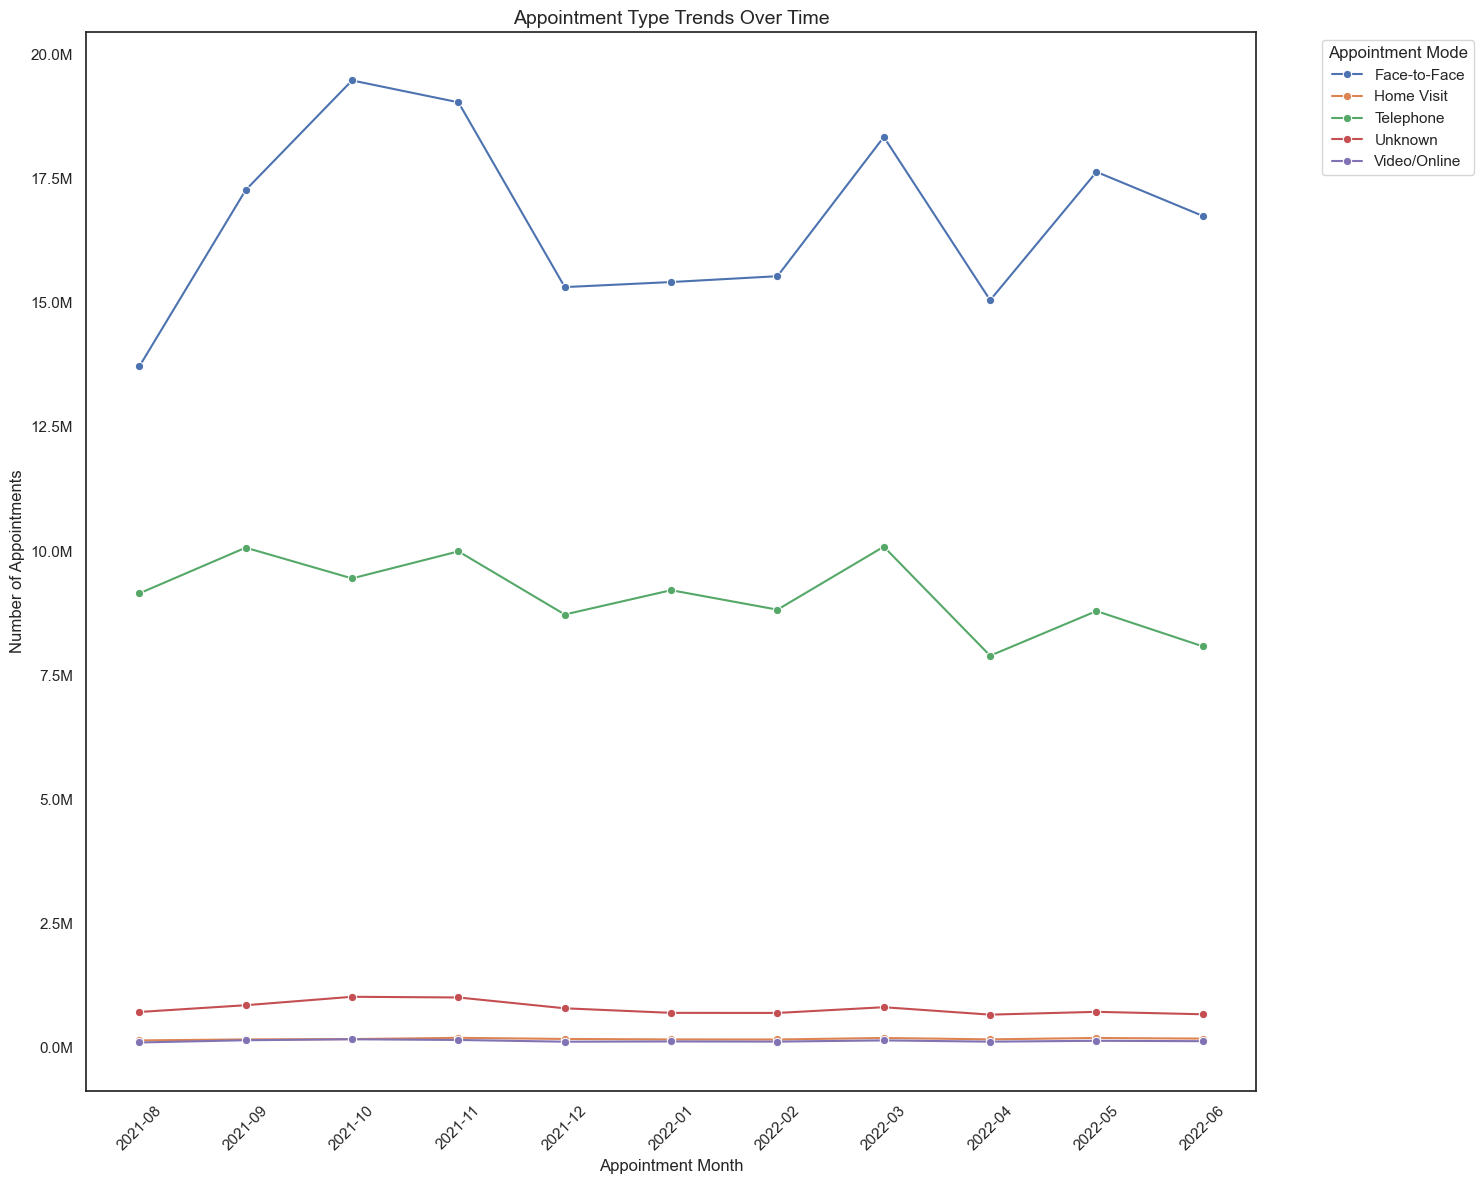

In [98]:
# Creating a line plot for mode_agg
ax = sns.lineplot(
    data=mode_agg,
    x='appointment_month_str',
    y='count_of_appointments',
    hue='appointment_mode',
    marker='o'
)

# Formatting title and axis
plt.title('Appointment Type Trends Over Time', fontsize=14)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)

# Moving legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Appointment Mode')

# View output
plt.tight_layout()
plt.show()

Whilst face-to-face monthly variance seems to align with general appointment crest and falls telephone appointments have less variance. We will now look at % of monthly totals.

In [99]:
# Calculate monthly totals
monthly_totals = (
    mode_agg
    .groupby('appointment_month_str')['count_of_appointments']
    .transform('sum')
)

# Create a new column for % of total per month
mode_agg['percent_of_month'] = (
    (mode_agg['count_of_appointments'] / monthly_totals) * 100
).round(1)

In [100]:
#View the output

mode_agg

,appointment_month_str,appointment_mode,count_of_appointments,percent_of_month
0,2021-08,Face-to-Face,13717325,57.5
1,2021-08,Home Visit,151619,0.6
2,2021-08,Telephone,9149072,38.4
3,2021-08,Unknown,724126,3.0
4,2021-08,Video/Online,110029,0.5
5,2021-09,Face-to-Face,17266602,60.5
6,2021-09,Home Visit,171829,0.6
7,2021-09,Telephone,10068770,35.3
8,2021-09,Unknown,859946,3.0
9,2021-09,Video/Online,155354,0.5


#### Observations
Face to Face appointments follow the overall appointment trends with the highest three months being Oct-21, Nov-21 and Mar-22. However, telephone appointments have much smaller variance and remain largely consistent irrespective of overall appointment variance.

### Analysing the time between booking and appointments

In [101]:
# Aggregating using time_between_book_and_appointment
book_time_agg = (
    ar_filtered
    .groupby(['appointment_month_str', 'time_between_book_and_appointment'])['count_of_appointments']
    .sum()
    .reset_index()
)

# View output
book_time_agg.head()

,appointment_month_str,time_between_book_and_appointment,count_of_appointments
0,2021-08,1 Day,2018319
1,2021-08,15 to 21 Days,1453209
2,2021-08,2 to 7 Days,4924960
3,2021-08,22 to 28 Days,828866
4,2021-08,8 to 14 Days,2889150


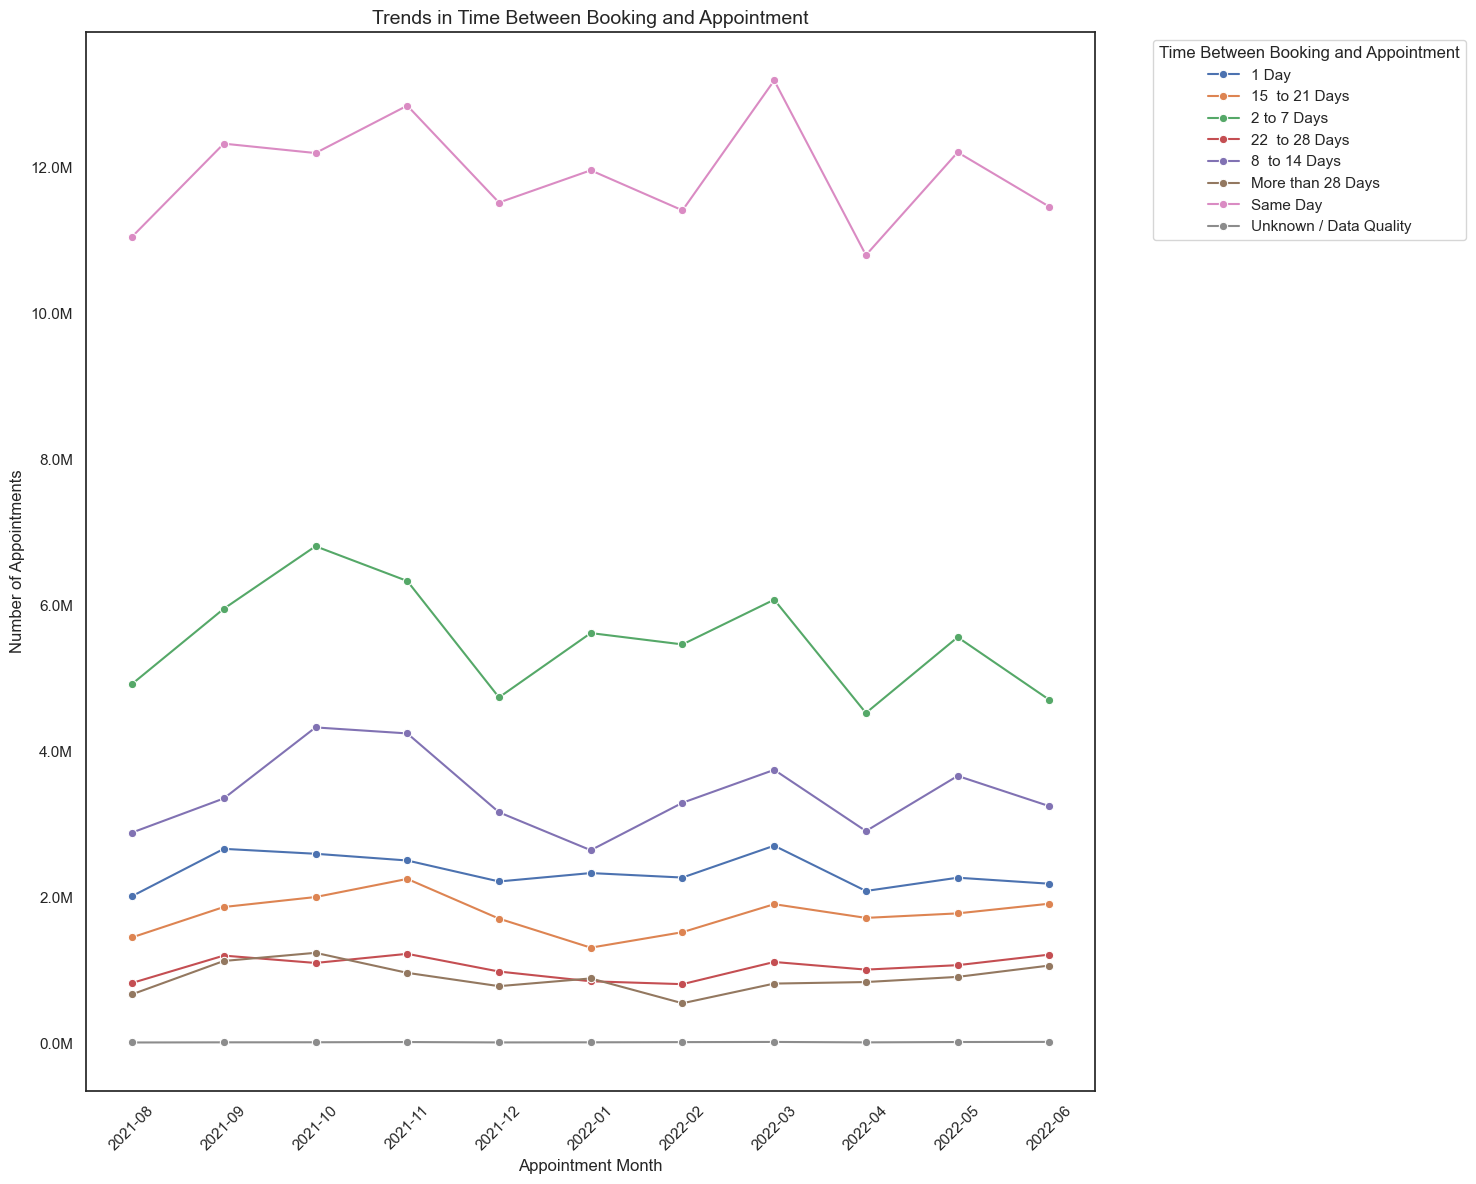

In [102]:
# Creating a line plot for book_time_agg
ax = sns.lineplot(
    data=book_time_agg,
    x='appointment_month_str',
    y='count_of_appointments',
    hue='time_between_book_and_appointment',
    marker='o'
)

# Formatting title and axis
plt.title('Trends in Time Between Booking and Appointment', fontsize=14)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)

# Moving legend outside of plot
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Time Between Booking and Appointment'
)

# View output
plt.tight_layout()
plt.show()

We will now group these times into 3 groups: Within 1 week, Between 1 and 2 weeks and greater than 2 weeks.

In [103]:
# Remove records with unknown or poor data quality
ar_filtered = ar_filtered[
    ar_filtered['time_between_book_and_appointment'] != 'Unknown / Data Quality'
]

# Strip white spaces
ar_filtered['time_between_book_and_appointment'] = (
    ar_filtered['time_between_book_and_appointment']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)  # Some categories had multiple spaces
)

# Create grouping dictionary
booking_groups = {
    'Same Day': 'Within 1 week',
    '1 Day': 'Within 1 week',
    '2 to 7 Days': 'Within 1 week',
    '8 to 14 Days': 'Between 1 and 2 weeks',
    '15 to 21 Days': 'Greater than 2 weeks',
    '22 to 28 Days': 'Greater than 2 weeks',
    'More than 28 Days': 'Greater than 2 weeks'
}

# Create a new column and apply grouping
ar_filtered['booking_group'] = (
    ar_filtered['time_between_book_and_appointment']
    .replace(booking_groups)
)

In [104]:
# Aggregating using new groupings
book_time_group_agg = (
    ar_filtered
    .groupby(['appointment_month_str', 'booking_group'])['count_of_appointments']
    .sum()
    .reset_index()
)

# View output
book_time_group_agg

,appointment_month_str,booking_group,count_of_appointments
0,2021-08,Between 1 and 2 weeks,2889150
1,2021-08,Greater than 2 weeks,2955300
2,2021-08,Within 1 week,17994283
3,2021-09,Between 1 and 2 weeks,3356476
4,2021-09,Greater than 2 weeks,4203038
5,2021-09,Within 1 week,20947479
6,2021-10,Between 1 and 2 weeks,4329393
7,2021-10,Greater than 2 weeks,4350560
8,2021-10,Within 1 week,21607414
9,2021-11,Between 1 and 2 weeks,4247246


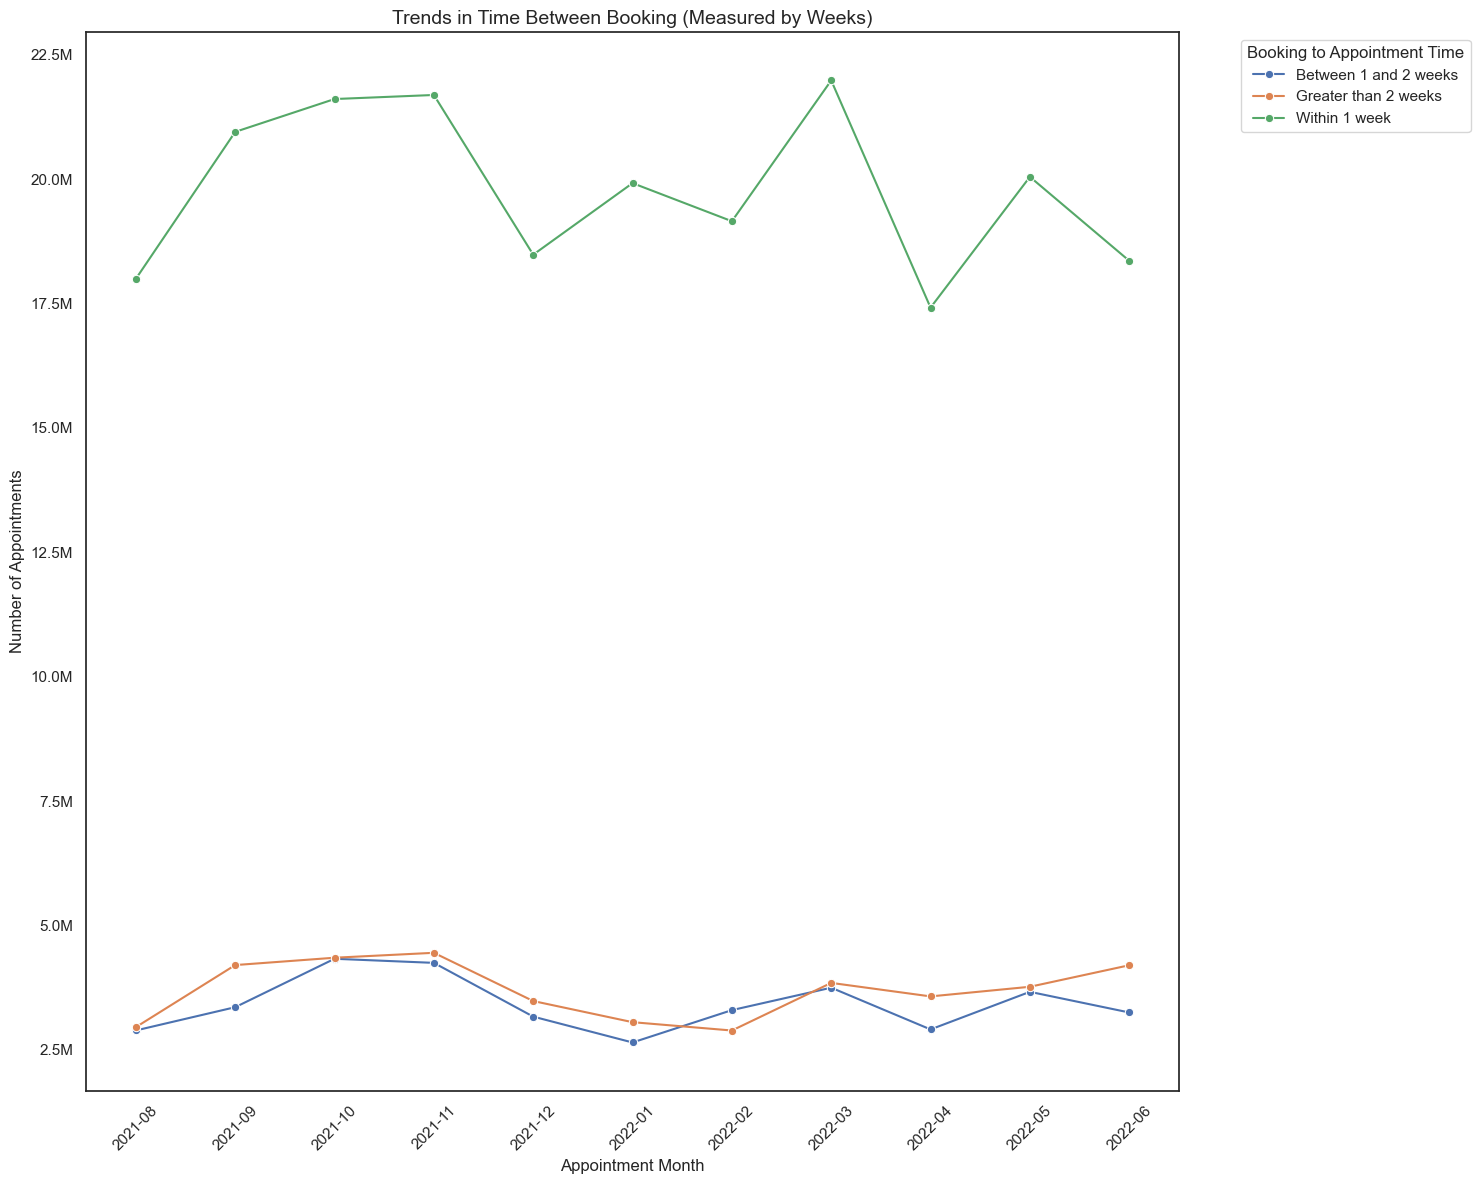

In [105]:
# Creating a line plot for the three timing groups
ax = sns.lineplot(
    data=book_time_group_agg,
    x='appointment_month_str',
    y='count_of_appointments',
    hue='booking_group',
    marker='o'
)

# Formatting the title and axis
plt.title('Trends in Time Between Booking (Measured by Weeks)', fontsize=14)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)  # Format y-axis in millions

# Moving the legend outside of the plot
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Booking to Appointment Time'
)

# View output
plt.tight_layout()
plt.show()

#### Observations
The large majority of appointments are within 1 week and even within that the biggest proportion are seen on the same day. However, the last three months of the data did show a slow but steady rise in appointments waiting for over 2 weeks even if total appointments fell. This should be monitored in subsequent months.

**Question 6:** How do the various service settings compare?

In [106]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,app_datetime,app_month_str,national_category_remap,season
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01,2021-08-02,2021-08-01,Other,Summer
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,2021-08-02,2021-08-01,Planned Clinics,Summer
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,2021-08-02,2021-08-01,Other,Summer
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,2021-08-02,2021-08-01,General Consultation Acute,Summer
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,2021-08-02,2021-08-01,Other,Summer


In [107]:
# Create a new DataFrame consisting of the month of appointment, service setting and the number of appointments.
nc_ss = (
    nc.groupby(
    ['app_month_str', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

# View Output
nc_ss

,app_month_str,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,160927
1,2021-08-01,General Practice,21575852
2,2021-08-01,Other,449101
3,2021-08-01,Primary Care Network,432448
4,2021-08-01,Unmapped,1233843
5,2021-09-01,Extended Access Provision,187906
6,2021-09-01,General Practice,25940821
7,2021-09-01,Other,527174
8,2021-09-01,Primary Care Network,530485
9,2021-09-01,Unmapped,1336115


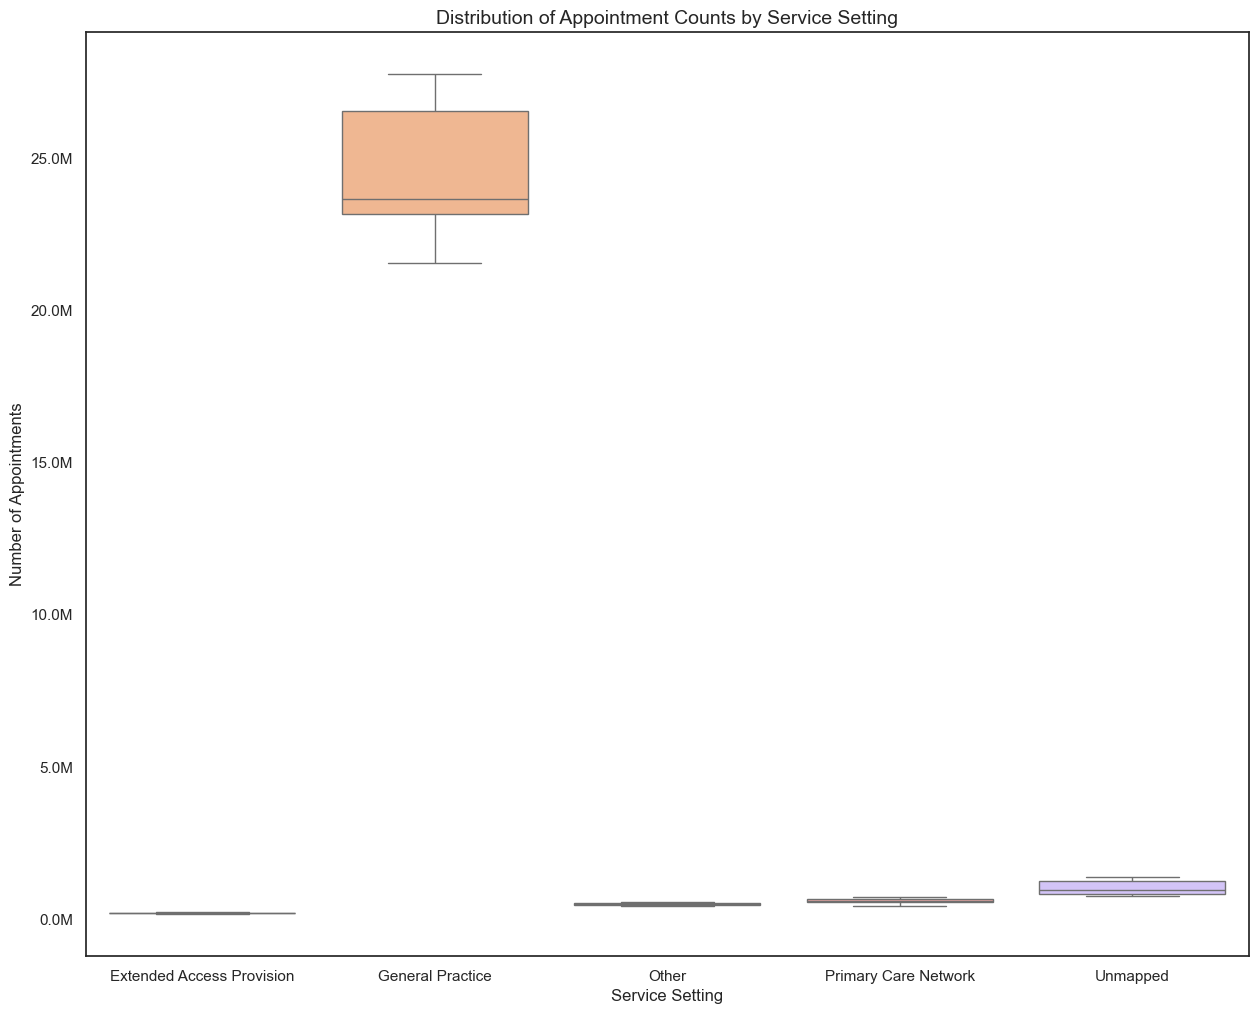

In [108]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
ax = sns.boxplot(
    data=nc_ss,
    x='service_setting',
    y='count_of_appointments',
    palette='pastel'
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)  # Format y-axis in millions

# Format title and axis
plt.title('Distribution of Appointment Counts by Service Setting', fontsize=14)
plt.xlabel('Service Setting', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)

# View output
plt.show()

This is not overly useful due to the dominance of General Practice appointments resulting in all other service setting box plots being heavily compaced on this scale. Therefore to better observe these we will filter out GP appointments.

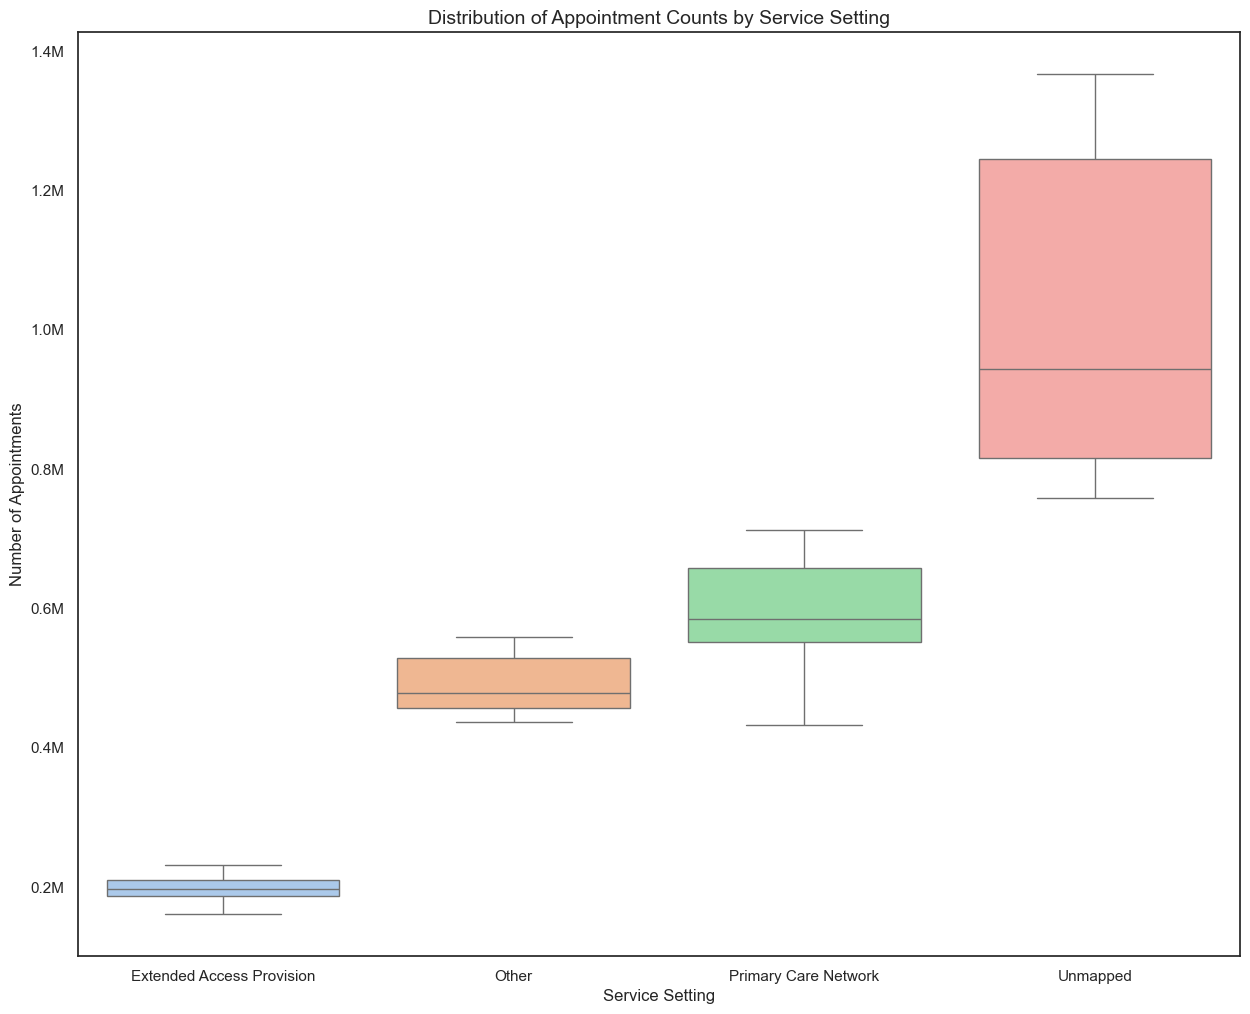

In [109]:
# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding GP visits.
# Apply filter to exclude GP appointments
nc_ss_nogp = nc_ss[nc_ss['service_setting'] != 'General Practice']

# Create the boxplot with new data subset
ax = sns.boxplot(
    data=nc_ss_nogp,
    x='service_setting',
    y='count_of_appointments',
    palette='pastel'
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M')
)  # Format y-axis in millions

# Format title and axis
plt.title('Distribution of Appointment Counts by Service Setting', fontsize=14)
plt.xlabel('Service Setting', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)

# View output
plt.show()

#### Observation
Currently this classification is heavily dominated by General Practice appointments. For future analysis it is recommended to look at General Practise seperately and then service settings together for scale. However, as mentioned in earlier sections there is a large amount of data here that is Unmapped. There is a large range for Unmapped indicating some months have significantly more unmapped appointment settings. The principle recommendation here would be to improve the mapping options and look to reduce the amount of Unmapped appointments for more accurate reporting.

### Provide a summary of your findings and recommendations based on the analysis.

#### Capacity
Given the provided capacity of 1.2m appointments a day then total capacity is not being currently exceeded. There is inherent assumption here that capacity supplied in different regions is proportional to the population (demand) in those regions. There is also an additional assumption that this daily capacity is for 30 days each month. In practice there may be months with lower capacity e.g. in Summer months or Christmas where more staff take holiday. Furthermore there is no accounting for weekends, particularly Sunday, where capacity may be lower. More detailed capacity estimates would be needed to anaylse further.

What is more likely an issue is allocation of capacity. The London regions serve a much bigger proportion of the UK population than other areas geographically such as Humber and Yorkshire. However, this hypothesis is not testable due to no data on the spread of capacity. It would be strongly recommended to break down daily capacity by region and compare to appointments in that region for a more accurate analysis.



#### Usage of network and seasonality
GP appointments forms a large majority of appointments (91.5%) but this is to be expected. There also appears to be less demand in Summer months as well for the main type of appointments (General Practice/General Consultation). Other, proportionally smaller, categories such as Planned Clincial Procedures do no exhibit seasonality and are consistent across the year.

Autumn appears to have the highest demand on capacity and this could possibly be linked to people coming back from Summer holidays and schools starting again. This would be an area recommended for further investigation.

#### Appointment methods and attendance

The number of monthly appointments not attended has remained relatively consistent across the analysed time period. This is interesting as it has not fluctuated in line with monthly demand fluctuations. By comparison the number of appointments attended does fluctuate proportionally with total monthly demand. This potentially indicates that the types of appointments most often missed are not general practice/consultation as otherwise you'd expect this to fluctuate in line with monthly demand.

One concerning trend identified in the final 3 months of the dataset was a  gradual but consistent increase in appointments being 2 weeks or more after booking. Wait time should always be minimised where possible and so this increase should be analysed further. This increase is not in line with general monthly fluctuations. 

#### Data Quality
Something consistently identified in this analysis is issues around data quality. Every categorical field has unmapped or unknown data entries. The numbers aren't insignificant either. In some categories for example Service Setting the 2nd largest value is 'Unmapped' and it has a large monthly range indicating with one month having nearly 1.4m unmapped appointments. For more accurate future analysis this must be addressed. Systems should be updated to not allow invalid or blank responses. Additionally training should be provided to staff who input the data explaining the categories and importance of data accuracy.
